# 조향각 CNN 전체 파이프라인: 라벨링 → 증강 → 학습(RTL 동일 INT8) → HW 추출

Google Drive 에 있는 **원본 데이터셋 여러 개**(zip 또는 폴더)를 이름으로 찾아 읽어서 한 번에 끝까지 진행합니다.

| 단계 | 내용 |
|---|---|
| 1. 라벨링 | 데이터셋마다 색상 마커(파랑 / 빨강 / 노랑)를 검출하고 자기 보정으로 조향각 계산. 데이터셋별로 QC 출력 |
| 2. 증강 | 데이터셋마다 블록 단위로 train / val / test 분할 → train 만 증강(밝기 올림 + 랜덤). RTL 과 같은 전처리로 64x64 로 만들어 메모리에 적재 |
| 3. 학습 | FP32 → calibration → QAT (RTL 정수 연산을 흉내) |
| 4. 추출 | COE, QM(VH), 시뮬레이션용 mem, 이어서 학습용 체크포인트 |

- 라벨링/증강 결과는 `OUT_DIR/cache` 에 저장되어, 다시 실행하면 바뀐 데이터셋만 새로 처리합니다.
- 라벨링이 실패한 데이터셋(유효 비율이 낮거나, 각도 분포가 한쪽으로 치우침)이 있으면 **학습 전에 멈춥니다.** 틀린 라벨로 학습하지 않기 위해서입니다.

## 0. 설정

In [1]:
# ===== 경로 (Google Drive) =====
DRIVE = '/content/drive/MyDrive/OndeviceAI2/Team_4/SoC/CNN/dataset_front_view'

# 원본 데이터셋 이름. DRIVE 아래(하위 폴더 포함)에서 '<이름>.zip' 또는 '<이름>' 폴더를 자동으로 찾습니다.
#   (이미지 파일 이름 순서 = 촬영 순서여야 합니다. 직접 경로를 주려면 이름 대신 전체 경로를 적어도 됩니다.)
DATASET_NAMES = [
    f'{DRIVE}/261005/dataset_261001_1926.zip',
    f'{DRIVE}/261005/dataset_261001_2030.zip',
    f'{DRIVE}/261005/dataset_261002_1400.zip',
    f'{DRIVE}/261005/dataset_261002_1700.zip',
    f'{DRIVE}/261005/dataset_261004_1530.zip',
    f'{DRIVE}/261005/dataset_261005_1243.zip',
    f'{DRIVE}/261005/dataset_261005_1500.zip',
    f'{DRIVE}/261006/dataset_261006_0700.zip',
    f'{DRIVE}/261006/dataset_261006_1100.zip',
    f'{DRIVE}/261007/dataset_261006_1300.zip',
]
OUT_DIR   = f'{DRIVE}/261006/pipeline_out'           # 결과 저장 (Drive)
WORK_DIR  = '/content/work'                   # 압축 푸는 임시 위치 (런타임 로컬)

USE_CACHE       = True     # 라벨링/증강 결과를 OUT_DIR/cache 에 저장하고, 설정이 같으면 다시 계산하지 않음
SHOW_DETAIL     = False    # True: 데이터셋마다 보정 과정 그림(궤적, 호 lookup, 흔들림, 무효/최악 프레임)까지 모두 표시
MIN_VALID_RATIO = 0.6      # 유효 라벨 비율이 이보다 낮은 데이터셋이 있으면 학습 전에 중단
MAX_FRAMES_PER_DATASET = 6000   # 데이터셋 하나에서 학습에 쓸 최대 프레임 수 (넘으면 고르게 추려 씀). 연속 프레임은 거의 같은 그림이라 손실이 작고, 메모리와 학습 시간을 줄임. None 이면 전부 사용
MAX_ZERO_SKEW   = 30.0     # 유효 각도의 5% 값과 95% 값이 좌우 대칭에서 이만큼(deg) 넘게 어긋나면 보정 실패로 보고 중단. 한쪽으로만 돌린 데이터셋이면 None

# ===== 배경 교체 증강 (모델이 옷 색/배경/팔 위치에 끌려가지 않게) =====
#   핸들(림 + 파란 피규어 + 받침대)만 남기고 나머지 배경을 임의의 색/무늬/다른 프레임으로 바꾼다. 라벨은 그대로.
BG_AUG        = True     # train 증강에 배경 교체를 포함
BG_P          = 0.7      # 랜덤 증강본 중 배경까지 바꿀 비율
N_BG_COPY     = 2        # train 원본마다 추가할 "배경을 바꾼" 사본 수
BG_TEST       = True     # test 원본의 배경을 바꾼 사본으로 따로 평가 (split = 'test_bg'). 배경에 얼마나 강한지 보는 지표
BG_TYPES      = dict(solid=0.15, bright=0.15, blobs=0.30, pattern=0.20, frame=0.20)   # 단색 / 밝은(하얗게 날아간) 배경 / 색 덩어리(옷·팔 흉내) / 줄무늬·체크 무늬(무늬 옷 흉내) / 다른 프레임의 배경(색상 변환)
BG_KEEP_RHO   = 1.18     # 림 타원(테이프 중심선)의 몇 배까지를 핸들로 보고 남길지
BG_FIG_R      = 0.30     # 파란 피규어 주변을 남길 반지름 (림 가로 반지름 대비)
BG_KEEP_BELOW = None     # None: 림 아래의 받침대/책상도 배경으로 보고 바꿈 (책상 색·밝기가 달라져도 버티게).  1.05 처럼 숫자를 주면 그 아래는 남김
BG_FEATHER    = 2.0      # 경계를 부드럽게 섞는 폭(px)
# 핸들의 크기/위치까지 바꿔서 다시 합성 (카메라 거리·높이가 달라져 핸들이 작게/위쪽에 찍히는 경우 대비)
BG_RECOMPOSE_P = 0.0             # 배경을 바꿀 때 핸들 크기/위치도 바꿀 확률. 기본은 끔: 일곱 데이터셋 비교에서 끈 쪽이 test 와 시연 영상 모두 더 좋았음 (0.6: test 5.7° / 영상 13.9°, 0: test 3.8° / 영상 12.3°)
BG_SCALE       = (0.65, 1.10)    # 핸들 크기 배율
BG_SHIFT       = (0.12, 0.15)    # 핸들 중심 이동 범위 (가로, 세로. 이미지 한 변 대비 ±)
BG_TABLE_P     = 0.5             # 새 배경 아래쪽에 책상(임의의 색 띠)을 그릴 확률
# 가짜 손: 림 위 임의의 위치에 피부색 덩어리를 얹음 (손 위치가 각도와 무관하다는 것을 배우게)
HAND_P         = 0.0             # 배경을 바꾼 사본에 가짜 손을 넣을 확률. 기본은 끔 (시연 영상 기준 비교에서 효과가 확인되지 않음). 써 보려면 0.4 정도
HAND_MAX       = 2               # 한 장에 넣는 최대 개수

# ===== 색상 임계값 (보정 후 HSV, OpenCV 기준 H: 0~179) =====
#   조명에 따라 마커 색이 크게 달라서 환경별로 두 벌을 두고, 이미지마다 밝기를 보고 자동으로 고른다.
HSV_PRESETS = {
    'bright': {   # 밝은 환경: 테이프가 옅게(채도 낮게) 찍히고, 검은 옷/받침대가 보정 후 어두운 남색으로 보임
        'blue':   dict(h=(75, 125), s_min=35, v_min=110),   # V 를 높게 잡아 어두운 남색(옷, 받침대, 림의 반사)을 제외
        'red':    dict(h=(172, 17), s_min=85, v_min=35),    # lo > hi 이면 hue wrap (H≈0 부근의 빨강까지 포함)
        'yellow': dict(h=(23, 40),  s_min=60, v_min=60),    # 피부(H≈16~22)는 hue 로 제외. 밝은 조명에서는 연두빛(H≈37)까지 감
    },
    'dark': {     # 어두운 환경: B 채널이 거의 0 이 되어 전체가 노랗게, 파란 마커는 연두색(H≈35)으로 보임
        'blue':   dict(h=(33, 125), s_min=30, s_max=240, v_min=50),
        'red':    dict(h=(4, 20),   s_min=130, v_min=35),
        'yellow': dict(h=(21, 31),  s_min=95,  v_min=60),   # 손도 같이 잡히지만 크기/위치/투표로 걸러짐
    },
}
DARK_REF  = 60               # (블랙레벨을 뺀) 밝은 상위 20% 의 대표 밝기가 이 값보다 작으면 'dark', 아니면 'bright'
HSV_FORCE = None             # 자동 선택 대신 'bright' 또는 'dark' 로 고정하려면 지정

# ===== 블롭 크기 조건 (256x256 기준, px^2) =====
BLUE_AREA_MIN = 60           # 파란 마커 최소 면적 (화면 가장자리에서 일부만 보이는 경우까지 후보로 씀)
BLUE_ZONE_RHO = (1.1, 1.7)   # 파란 마커가 있을 수 있는 영역: 림 타원 반지름의 몇 배 바깥인지 (림 안쪽의 기둥 반사 등은 제외)
TAPE_AREA     = (50, 350)    # 림 테이프(빨강/노랑) 면적 범위
ARC_AREA_MIN  = 40           # 허브 노란 호 최소 면적

# ===== 마커 배치 (파란 마커 기준 시계방향 +, 대략값. 정확한 값은 보정 단계에서 자동 추정) =====
LAYOUT_DEG = {'R1': -40, 'R2': -142, 'Y1': 40, 'Y2': 142}
ASSIGN_TOL = 12              # 보정용 초기 매칭 허용 오차(deg)

# ===== 각도 추정 =====
RHO_TOL     = (0.85, 1.15)   # 펴진 평면에서 마커 반지름 허용 범위 (1.0 = 정확히 궤도 위)
ARC_RHO_MAX = 0.55           # 이 반지름보다 안쪽의 노란 블롭은 허브 호로 취급
VOTE_TOL    = 5.0            # 마커들이 같은 각도라고 인정하는 범위(deg)
THETA_LIMIT = 100.0          # 물리적으로 가능한 최대 조향각(deg)
W_BLUE      = 2.0            # 파란 마커 가중치 (테이프는 1.0)
MIN_SCORE   = 3.0            # 유효 판정 최소 점수 (예: 파랑+테이프1, 또는 테이프3)
ARC_TOL     = 20.0           # 허브 호와 이 이상 어긋나면 무효 처리
ARC_OVERRIDE_SCORE = 4.0     # 단, 마커 점수가 이 이상이면(예: 파랑+테이프2, 테이프4) 호와 어긋나도 유효로 둠
TEMPORAL_TOL = 35.0          # 연속 촬영 기준: 앞뒤 3프레임(유효한 것)의 중앙값과 이 이상 차이 나면 무효. 연속 촬영이 아니면 None

# ===== 카메라/거치대 흔들림 보정 =====
USE_SHIFT_CORRECTION = True  # 프레임별 핸들 중심 이동(px)을 추정해서 보정
SHIFT_WIN            = 31    # 중심 이동량 median 필터 길이(프레임, 홀수)

# ===== 라벨 규약 =====
ANGLE_SIGN    = -1           # -1: 사진에서 왼쪽(반시계)으로 돌리면 +, 오른쪽이면 -.   +1: 반대
ZERO_TRIM_DEG = 0.0          # 0도 기준 미세 조정 (최종 각도에 더해짐)
ANGLE_NORM    = 90.0         # angle_norm = angle_deg / ANGLE_NORM

# ===== 데이터 분할 =====
SPLIT_RATIO = dict(val=0.10, test=0.10)   # 나머지는 train
SPLIT_BLOCK = 40             # 연속 프레임을 이 길이의 블록 단위로 묶어서 분할 (인접 프레임 누수 방지)
SPLIT_SEED  = 0

# ===== 데이터 증강 : train 에만 적용, 라벨은 그대로 =====
N_AUG       = 2              # 원본 1장당 증강본 수 (기준값)
BALANCE     = True           # True: 장수가 적은 각도 구간은 증강본을 더 많이 만들어 분포를 고르게 함
AUG_RANGE   = (1, 6)         # BALANCE 사용 시 원본 1장당 증강본 수의 (최소, 최대)
BALANCE_BIN = 10             # 각도 구간 폭(deg)
AUG_SEED    = 0
ADD_BRIGHT  = True           # True: train 원본마다 "밝기만 약간 올린" 사본을 1장씩 추가 (다른 변형 없음)
BRIGHT_GAIN = 1.25           # 밝기 배율 (1.25 = 25% 밝게). 255 를 넘는 값은 255 로 잘림

AUG = dict(
    shift_px   = 12,             # 이동 ±px (256 기준. 64x64 로 줄이면 ±3px)
    zoom       = (0.94, 1.06),   # 확대/축소
    exposure   = (0.70, 1.60),   # 전체 노출 배율 (밝게 날아간 영상 / 어두운 영상 대비)
    gain       = 0.06,           # 채널별 gain ±6% (색감 차이)
    brightness = 18,             # 밝기 ±
    contrast   = (0.80, 1.25),
    saturation = (0.75, 1.25),
    gamma      = (0.75, 1.35),
    blur_p     = 0.30,           # Gaussian blur 확률 (sigma 0.4~1.2)
    noise_p    = 0.50,           # Gaussian noise 확률 (sigma 2~7)
    cutout_p   = 0.30,           # 작은 사각형 가림 확률 (손/소매)
    cutout_frac = (0.06, 0.16),  # 가림 한 변 크기 (이미지 한 변 대비)
)

# ===== RTL 캡처 설정 (main.c 의 CAPTURE_CROP_X / CAPTURE_CROP_Y) =====
CROP_X, CROP_Y = 0, 464      # 이미지가 1280x720 원본일 때만 사용. 256x256 이미지는 이미 crop 된 것으로 보고 4x4 평균만 함

# ===== 이어서 학습 =====
RESUME_FROM = None           # 이어서 학습하려면 체크포인트 경로 (.zip 또는 .pt). None 이면 처음부터 학습

# ===== 학습 =====
EPOCHS_FP32  = 40            # ① FP32 학습 epoch 수 (누적 기준. 이어서 더 돌리려면 이 값을 키움)
EPOCHS_QAT   = 20            # ③ QAT epoch 수 (누적 기준)
BATCH        = 128
LR_FP32      = 2e-3
LR_QAT       = 5e-4
WEIGHT_DECAY = 1e-4
SEED         = 0

# ===== 양자화 =====
ACT_PERCENTILE = 99.9        # activation scale = 이 백분위 값 / 127

# ===== export =====
BASE_COE       = f'{DRIVE}/261002/Weight_Bias_Image_260928_1406.coe'   # 뒤쪽(word 45293~)을 복사해 올 기존 COE. 없으면 0 으로 채움
N_TEST_VECTORS = 5           # img.mem / expected_angles.mem 에 넣을 test 이미지 수

## 1. 준비

In [2]:
import os, io, re, json, time, glob, zipfile, random, hashlib
import numpy as np
import pandas as pd
import cv2
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.signal import medfilt

try:                                   # Colab 이면 Drive 연결
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

plt.rcParams['figure.dpi'] = 80
os.makedirs(OUT_DIR, exist_ok=True); os.makedirs(os.path.join(OUT_DIR, 'cache'), exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
STAMP = time.strftime('%Y%m%d_%H%M')
print('device:', DEVICE, '| torch', torch.__version__)

def find_datasets(names, root):
    # root 아래를 훑어 '<이름>.zip' 또는 '<이름>' 폴더를 찾는다 (zip 이 있으면 zip 우선: Drive 에서 읽기가 훨씬 빠름)
    want = [n for n in names if not os.path.exists(n)]
    hit_zip, hit_dir = {}, {}
    for cur, dirs, fnames in os.walk(root):
        for n in want:
            if n + '.zip' in fnames: hit_zip.setdefault(n, os.path.join(cur, n + '.zip'))
            if n in dirs: hit_dir.setdefault(n, os.path.join(cur, n))
        dirs[:] = [d for d in dirs if d not in want and d not in ('pipeline_out', 'cache', 'qc')]   # 데이터셋 폴더 안/결과 폴더는 들어가지 않음
    return [n if os.path.exists(n) else hit_zip.get(n) or hit_dir.get(n) for n in names]

DATASET_ZIPS = find_datasets(DATASET_NAMES, DRIVE)
missing = [n for n, p in zip(DATASET_NAMES, DATASET_ZIPS) if p is None]
assert not missing, f'{DRIVE} 아래에서 찾지 못한 데이터셋: {missing}'
for p in DATASET_ZIPS: print('  사용:', p)
DS_NAMES = [os.path.splitext(os.path.basename(p.rstrip('/')))[0] for p in DATASET_ZIPS]
assert len(set(DS_NAMES)) == len(DS_NAMES), '데이터셋 이름(파일명)이 겹칩니다'
print('데이터셋:', DS_NAMES)

def dataset_files(path, name):
    # zip 이면 WORK_DIR 에 풀고, 이미지 경로를 파일명 순으로 반환
    if path.lower().endswith('.zip'):
        d = os.path.join(WORK_DIR, 'raw', name)
        if not os.path.isdir(d):
            with zipfile.ZipFile(path) as z: z.extractall(d)
    else:
        d = path
    files = sorted(glob.glob(os.path.join(d, '**', '*.png'), recursive=True))
    assert files, f'{name}: PNG 이미지를 찾지 못했습니다'
    return files

Mounted at /content/drive
device: cuda | torch 2.11.0+cu130
  사용: /content/drive/MyDrive/OndeviceAI2/Team_4/SoC/CNN/dataset_front_view/261005/dataset_261001_1926.zip
  사용: /content/drive/MyDrive/OndeviceAI2/Team_4/SoC/CNN/dataset_front_view/261005/dataset_261001_2030.zip
  사용: /content/drive/MyDrive/OndeviceAI2/Team_4/SoC/CNN/dataset_front_view/261005/dataset_261002_1400.zip
  사용: /content/drive/MyDrive/OndeviceAI2/Team_4/SoC/CNN/dataset_front_view/261005/dataset_261002_1700.zip
  사용: /content/drive/MyDrive/OndeviceAI2/Team_4/SoC/CNN/dataset_front_view/261005/dataset_261004_1530.zip
  사용: /content/drive/MyDrive/OndeviceAI2/Team_4/SoC/CNN/dataset_front_view/261005/dataset_261005_1243.zip
  사용: /content/drive/MyDrive/OndeviceAI2/Team_4/SoC/CNN/dataset_front_view/261005/dataset_261005_1500.zip
  사용: /content/drive/MyDrive/OndeviceAI2/Team_4/SoC/CNN/dataset_front_view/261006/dataset_261006_0700.zip
  사용: /content/drive/MyDrive/OndeviceAI2/Team_4/SoC/CNN/dataset_front_view/261006/dataset_26

## 2. 라벨링 함수

`label_dataset(name, files, OUT_DIR)` 하나가 데이터셋 한 개의 라벨링 전체를 수행합니다 (색 보정 → 마스크 → 자기 보정 → 각도 투표 → 흔들림 보정 → 유효성 검사 → QC).  
카메라 위치와 테이프 배치가 데이터셋마다 다를 수 있으므로 보정은 **데이터셋마다 따로** 합니다.

부호 규약: `ANGLE_SIGN = -1` (기본값) 이면 사진에서 파란 마커가 **왼쪽**으로 갈 때 +, 오른쪽으로 갈 때 - 입니다. 0° 는 림의 12시 지점(위쪽 빨강·노랑 테이프의 가운데)이 림 중심 바로 위에 올 때입니다.

In [3]:
def label_dataset(name, files, OUT_DIR):
    # 데이터셋 하나를 라벨링해서 DataFrame(filename, angle_deg, valid, ...) 을 반환. QC 그림은 OUT_DIR 에 저장
    N = len(files)
    H_IMG, W_IMG = cv2.imread(files[0]).shape[:2]
    os.makedirs(OUT_DIR, exist_ok=True)
    wrap = lambda d: (d + 180.0) % 360.0 - 180.0

    KERNEL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

    WB_GAIN_LIMIT = (0.8, 1.25)   # 채널별 화이트밸런스 gain 허용 범위

    def white_balance(img_bgr):
        # 블랙레벨 제거 + (제한된) 화이트밸런스 + 밝기 정규화
        f = cv2.GaussianBlur(img_bgr.astype(np.float32), (3, 3), 0)
        black = np.percentile(f.reshape(-1, 3), 3, axis=0)
        f = np.clip(f - black, 0, None)
        lum = f.sum(axis=2)
        white = np.maximum(np.median(f[lum >= np.percentile(lum, 80)], axis=0), 1.0)     # 밝은 상위 20% 의 대표색
        # 밝은 영상: 옷/배경이 무채색 기준이 되어 약한 색 치우침을 바로잡는다 (gain 이 범위 안).
        # 어두운 영상: 기준이 손/테이프뿐이고 B 채널이 0 에 가까워 gain 이 폭주하므로 범위로 잘라 사실상 보정하지 않는다.
        f = f * np.clip(white.mean() / white, *WB_GAIN_LIMIT)
        ref = np.median(f.mean(axis=2)[lum >= np.percentile(lum, 80)])                    # 밝은 영역의 대표 밝기 → 200 으로
        peak = np.percentile(f.max(axis=2), 99.0)                                         # 가장 밝은 1% 가 포화되지 않게 제한
        return np.clip(f * min(200.0 / max(ref, 1.0), 235.0 / max(peak, 1.0)), 0, 255).astype(np.uint8)

    def scene_env(img_bgr):
        # 원본 이미지의 밝기로 환경('bright' / 'dark') 판정
        if HSV_FORCE: return HSV_FORCE
        f = img_bgr.astype(np.float32)
        lum = np.clip(f - np.percentile(f.reshape(-1, 3), 3, axis=0), 0, None).mean(axis=2)
        return 'dark' if np.median(lum[lum >= np.percentile(lum, 80)]) < DARK_REF else 'bright'

    def color_masks(img_wb, env):
        H, S, V = cv2.split(cv2.cvtColor(img_wb, cv2.COLOR_BGR2HSV))
        out = {}
        for name, r in HSV_PRESETS[env].items():
            lo, hi = r['h']
            hue_ok = (H >= lo) & (H <= hi) if lo <= hi else (H >= lo) | (H <= hi)   # lo>hi 이면 hue wrap
            m = (hue_ok & (S >= r['s_min']) & (S <= r.get('s_max', 255)) & (V >= r['v_min'])).astype(np.uint8) * 255
            m = cv2.morphologyEx(m, cv2.MORPH_OPEN, KERNEL)
            m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, KERNEL)
            out[name] = m
        return out

    def find_blobs(mask, area_min=15):
        # 반환: (n, 8) 배열 [cx, cy, area, x0, y0, w, h, tilt]
        #   tilt = 블롭 장축의 기울기(deg, -90~90, 수평=0, 이미지에서 시계방향으로 기울면 +)
        n, lab, stats, cent = cv2.connectedComponentsWithStats(mask, 8)
        rows = []
        for i in range(1, n):
            x0, y0, w, h, area = stats[i]
            if area < area_min: continue
            mo = cv2.moments((lab[y0:y0 + h, x0:x0 + w] == i).astype(np.uint8), binaryImage=True)
            tilt = 0.5 * np.degrees(np.arctan2(2 * mo['mu11'], mo['mu20'] - mo['mu02']))
            rows.append((cent[i][0], cent[i][1], area, x0, y0, w, h, tilt))
        return np.array(rows, dtype=np.float64).reshape(-1, 8)

    DRAW_COLOR = {'blue': (255, 128, 0), 'red': (0, 0, 255), 'yellow': (0, 255, 255)}   # BGR

    def show_masks(indices):
        fig, axes = plt.subplots(3, len(indices), figsize=(2.6 * len(indices), 8))
        for c, i in enumerate(indices):
            img = cv2.imread(files[i]); wbi = white_balance(img); env = scene_env(img); m = color_masks(wbi, env)
            ov = (wbi * 0.35).astype(np.uint8)
            for k in m: ov[m[k] > 0] = DRAW_COLOR[k]
            for r, (im, t) in enumerate([(img, f'#{i} raw'), (wbi, 'corrected'), (ov, f'mask ({env})')]):
                axes[r, c].imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); axes[r, c].set_title(t, fontsize=9); axes[r, c].axis('off')
        plt.tight_layout(); plt.show()

    # 임계값을 바꾸면 이 셀로 먼저 확인 (마스크 제목의 괄호 = 자동 판정된 환경)
    show_masks(np.linspace(0, N - 1, 6).astype(int))

    blobs, envs = [], []
    for i, f in enumerate(files):
        img = cv2.imread(f); envs.append(scene_env(img))
        m = color_masks(white_balance(img), envs[-1])
        blobs.append({k: find_blobs(m[k]) for k in m})
        if (i + 1) % 500 == 0 or i + 1 == N:
            print(f'\r{i + 1}/{N}', end='')

    def touches_border(b):
        return b[3] <= 1 or b[4] <= 1 or b[3] + b[5] >= W_IMG - 1 or b[4] + b[6] >= H_IMG - 1

    print('\n환경 판정:', {e: envs.count(e) for e in sorted(set(envs))})

    def fit_axis_ellipse(x, y, iters=5):
        # 축 정렬 타원 A x^2 + C y^2 + D x + E y = 1 의 강건 최소자승 피팅
        w = np.ones(len(x), bool)
        for _ in range(iters):
            M = np.c_[x[w] ** 2, y[w] ** 2, x[w], y[w]]
            A, C, D, E = np.linalg.lstsq(M, np.ones(w.sum()), rcond=None)[0]
            cx, cy = -D / (2 * A), -E / (2 * C)
            k = 1 + A * cx ** 2 + C * cy ** 2
            a, b = np.sqrt(k / A), np.sqrt(k / C)
            r = np.hypot((x - cx) / a, (y - cy) / b) - 1
            s = 1.4826 * np.median(np.abs(r[w] - np.median(r[w]))) + 1e-6
            w = np.abs(r) < 3 * s
        return cx, cy, a, b

    def fit_ring_ransac(x, y, iters=600, tol=0.05, seed=0):
        # 점 4개로 축 정렬 타원을 만들어 보고, 그 타원 위(±tol)에 놓인 점이 가장 많은 것을 고른다.
        # 옷·손에서 생긴 잡음 블롭이 많거나 림의 일부(위쪽 반)만 보여도 테이프가 지나간 고리를 찾을 수 있다.
        rng = np.random.default_rng(seed)
        if len(x) > 6000:
            k = rng.choice(len(x), 6000, replace=False); x, y = x[k], y[k]
        best_n, best = -1, None
        for _ in range(iters):
            i = rng.choice(len(x), 4, replace=False)
            try:
                A, C, D, E = np.linalg.solve(np.c_[x[i] ** 2, y[i] ** 2, x[i], y[i]], np.ones(4))
            except np.linalg.LinAlgError:
                continue
            if A * C <= 0: continue                                   # 타원이 아님
            cx, cy = -D / (2 * A), -E / (2 * C)
            k = 1 + A * cx ** 2 + C * cy ** 2
            if k / A <= 0: continue
            a, b = np.sqrt(k / A), np.sqrt(k / C)
            if not (0.2 * W_IMG < a < 0.6 * W_IMG and 0.5 < b / a < 1.1 and 0.3 * W_IMG < cx < 0.7 * W_IMG and 0.2 * H_IMG < cy < 0.8 * H_IMG): continue
            n = int((np.abs(np.hypot((x - cx) / a, (y - cy) / b) - 1) < tol).sum())
            if n > best_n: best_n, best = n, (cx, cy, a, b)
        cx, cy, a, b = best
        inl = np.abs(np.hypot((x - cx) / a, (y - cy) / b) - 1) < 2 * tol
        return fit_axis_ellipse(x[inl], y[inl])

    # 림 위의 테이프(빨강 + 노랑) 중심점을 모두 모아 고리를 찾는다. 두 색을 같이 써야 림의 왼쪽·오른쪽이 고르게 채워진다.
    tape_all = np.vstack([bl[c] for bl in blobs for c in ('red', 'yellow')])
    tape_all = tape_all[(tape_all[:, 2] >= TAPE_AREA[0]) & (tape_all[:, 2] <= TAPE_AREA[1])]
    red_all = tape_all
    red_only = np.vstack([bl['red'] for bl in blobs])
    red_only = red_only[(red_only[:, 2] >= TAPE_AREA[0]) & (red_only[:, 2] <= TAPE_AREA[1])]
    # 후보 두 개 중 "파란 마커 기준으로 예상 위치에 테이프가 더 많이 놓이는" 쪽을 고른다.
    #   (1) 빨강만으로 최소자승: 림 전체가 보이고 잡음이 적은 촬영에서 가장 정확
    #   (2) 빨강 + 노랑으로 RANSAC: 림의 위쪽 반만 보이거나 옷 색이 빨강으로 잡히는 촬영에서도 버팀
    #   타원이 틀리면 각도가 일그러져서 테이프가 예상 위치(LAYOUT_DEG)에서 벗어나므로 맞는 개수가 줄어든다.
    def geom_score(e):
        cx, cy, ra, rb = e
        wrap_ = lambda d: (d + 180.0) % 360.0 - 180.0
        total = 0
        for bl in blobs[::max(1, N // 1500)]:
            Bm = bl['blue']
            if len(Bm) == 0: continue
            ub, vb = (Bm[:, 0] - cx) / ra, (Bm[:, 1] - cy) / rb
            rho_b, phi_b = np.hypot(ub, vb), np.degrees(np.arctan2(ub, -vb))
            okb = (Bm[:, 2] >= BLUE_AREA_MIN) & (rho_b >= BLUE_ZONE_RHO[0]) & (rho_b <= BLUE_ZONE_RHO[1]) & (np.abs(phi_b) <= THETA_LIMIT + 15)
            best = 0
            for pb in phi_b[okb]:
                m = 0
                for color, offs in (('red', (LAYOUT_DEG['R1'], LAYOUT_DEG['R2'])), ('yellow', (LAYOUT_DEG['Y1'], LAYOUT_DEG['Y2']))):
                    T = bl[color]
                    T = T[(T[:, 2] >= TAPE_AREA[0]) & (T[:, 2] <= TAPE_AREA[1])]
                    if len(T) == 0: continue
                    u, v = (T[:, 0] - cx) / ra, (T[:, 1] - cy) / rb
                    rho, phi = np.hypot(u, v), np.degrees(np.arctan2(u, -v))
                    for o in offs:
                        m += int(((np.abs(rho - 1) < 0.12) & (np.abs(wrap_(phi - pb - o)) < ASSIGN_TOL + 6)).any())
                best = max(best, m)
            total += best
        return total

    cands = [fit_axis_ellipse(red_only[:, 0], red_only[:, 1]), fit_ring_ransac(tape_all[:, 0], tape_all[:, 1])]
    scores = [geom_score(e) for e in cands]
    CX, CY, RA, RB = cands[int(np.argmax(scores))]
    print('림 타원 후보별로 예상 위치에 맞은 테이프 수: 최소자승 %d, RANSAC %d → %s 사용' % (scores[0], scores[1], ['최소자승', 'RANSAC'][int(np.argmax(scores))]))

    def in_blue_zone(b):
        # 파란 마커는 림 바깥쪽, 위쪽 반원에만 올 수 있다. 림 안쪽(기둥 반사)이나 아래쪽(받침대)의 파란 블롭은 마커가 아니다.
        u, v = (b[0] - CX) / RA, (b[1] - CY) / RB
        return BLUE_ZONE_RHO[0] <= np.hypot(u, v) <= BLUE_ZONE_RHO[1] and abs(np.degrees(np.arctan2(u, -v))) <= THETA_LIMIT + 15

    def blue_blob(bl):
        # 파란 마커 영역 안의 가장 큰 파란 블롭 (없으면 None)
        B = [b for b in bl['blue'] if b[2] >= BLUE_AREA_MIN and in_blue_zone(b)]
        return max(B, key=lambda b: b[2]) if B else None

    blue_xy = np.array([b[:2] if (b := blue_blob(bl)) is not None else (np.nan, np.nan) for bl in blobs])
    blue_rho0 = np.nanmedian(np.hypot((blue_xy[:, 0] - CX) / RA, (blue_xy[:, 1] - CY) / RB))   # 파란 마커 궤도 / 림 궤도 비율
    print(f'파란 마커 영역에서 검출: {int(np.isfinite(blue_xy[:, 0]).sum())}/{N} 프레임')
    print(f'림 타원: 중심=({CX:.1f}, {CY:.1f}), 반축 a={RA:.1f}, b={RB:.1f}  |  파란 마커 궤도 비율={blue_rho0:.3f}')

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(cv2.cvtColor(white_balance(cv2.imread(files[0])), cv2.COLOR_BGR2RGB), alpha=0.5)
    ax.scatter(red_all[:, 0], red_all[:, 1], s=1, c='r')    # 테이프(빨강 + 노랑) 중심점
    ax.scatter(blue_xy[:, 0], blue_xy[:, 1], s=1, c='b')  # 파랑 마커 궤적
    t = np.linspace(0, 2 * np.pi, 200)
    ax.plot(CX + RA * np.cos(t), CY + RB * np.sin(t), 'w--', lw=1)
    ax.plot(CX, CY, 'w+'); ax.set_title('marker trajectories (all frames)'); ax.axis('off'); (plt.show() if SHOW_DETAIL else plt.close())

    MARKERS = ['B', 'R1', 'R2', 'Y1', 'Y2']
    wrap = lambda d: (d + 180.0) % 360.0 - 180.0

    def rectify(Gm, x, y):
        w = Gm[2, 0] * x + Gm[2, 1] * y + Gm[2, 2]
        return (Gm[0, 0] * x + Gm[0, 1] * y + Gm[0, 2]) / w, (Gm[1, 0] * x + Gm[1, 1] * y + Gm[1, 2]) / w

    def ell_polar(x, y):
        # 초기 타원 기준 (각도[deg, 위쪽=0, 시계방향+], 정규화 반지름)
        u, v = (x - CX) / RA, (y - CY) / RB
        return np.degrees(np.arctan2(u, -v)), np.hypot(u, v)

    # --- 테이프 배치 초기값 맞추기: (테이프 각도 - 파란 마커 각도) 의 실제 분포로 LAYOUT_DEG 를 보정 ---
    #   테이프를 다시 붙였거나 위치가 설정값과 몇 도 달라도 관측을 놓치지 않게 한다.
    offs = {'red': [], 'yellow': []}
    for bl in blobs:
        b = blue_blob(bl)
        if b is None: continue
        phi_b, rho_b = ell_polar(b[0], b[1])
        if not (0.85 * blue_rho0 < rho_b < 1.15 * blue_rho0): continue
        for color in offs:
            for t in bl[color]:
                phi, rho = ell_polar(t[0], t[1])
                if TAPE_AREA[0] <= t[2] <= TAPE_AREA[1] and 0.8 < rho < 1.25:
                    offs[color].append(wrap(phi - phi_b))
    LAYOUT = dict(LAYOUT_DEG)
    for nm in LAYOUT:
        o = np.array(offs['red' if nm[0] == 'R' else 'yellow'])
        for _ in range(3):
            near = wrap(o - LAYOUT[nm]); near = near[np.abs(near) < 20]
            if len(near) >= 30: LAYOUT[nm] = float(wrap(LAYOUT[nm] + np.median(near)))
    print('테이프 배치 초기값(deg):', {k: round(v, 1) for k, v in LAYOUT.items()}, ' (설정값:', LAYOUT_DEG, ')')

    # --- 관측 수집: 파랑 기준 오프셋으로 테이프를 식별 (화면 경계에 잘린 블롭은 중심이 틀어지므로 관측에서 제외) ---
    #   배경에 파랗게 잡히는 물체가 있을 수 있으므로, 파란 블롭 후보 중 "예상 위치에 테이프가 가장 많이 있는" 것을 진짜 마커로 본다.
    def tape_matches(bl, phi_b):
        found = []
        for color, names in (('red', ('R1', 'R2')), ('yellow', ('Y1', 'Y2'))):
            for t in bl[color]:
                if not (TAPE_AREA[0] <= t[2] <= TAPE_AREA[1]) or touches_border(t): continue
                phi, rho = ell_polar(t[0], t[1])
                if not (0.8 < rho < 1.25): continue
                for nm in names:
                    if abs(wrap(phi - phi_b - LAYOUT[nm])) < ASSIGN_TOL:
                        found.append((MARKERS.index(nm), t[0], t[1]))
        return found

    obs = []   # (frame, marker_idx, x, y)
    for i, bl in enumerate(blobs):
        best = None
        for b in bl['blue']:
            phi_b, rho_b = ell_polar(b[0], b[1])
            if b[2] < BLUE_AREA_MIN or not in_blue_zone(b) or not (0.85 * blue_rho0 < rho_b < 1.15 * blue_rho0): continue
            m = tape_matches(bl, phi_b)
            if m and (best is None or (len(m), b[2]) > (len(best[1]), best[0][2])):
                best = (b, m)
        if best is None: continue
        b, m = best
        if not touches_border(b): obs.append((i, 0, b[0], b[1]))
        obs += [(i, k, x, y) for k, x, y in m]
    obs = np.array(obs)
    o_f, o_k, o_x, o_y = obs[:, 0].astype(int), obs[:, 1].astype(int), obs[:, 2], obs[:, 3]
    print('보정용 관측 수:', dict(zip(MARKERS, np.bincount(o_k, minlength=5).tolist())))

    def unpack(p):
        Gt = np.array([[p[0], p[1], p[2]], [p[3], p[4], p[5]], [p[6], p[7], 1.0]])
        Gb = np.array([[p[8], p[9], p[10]], [p[11], p[12], p[13]], [p[14], p[15], 1.0]])
        alpha = np.r_[0.0, p[16:20]]          # rad, 파랑은 0 으로 고정
        return Gt, Gb, alpha

    def obs_angles(p):
        Gt, Gb, alpha = unpack(p)
        qx, qy = rectify(Gt, o_x, o_y); bx, by = rectify(Gb, o_x, o_y)
        qx = np.where(o_k == 0, bx, qx); qy = np.where(o_k == 0, by, qy)
        return np.arctan2(qx, qy) - alpha[o_k], np.hypot(qx, qy)

    def frame_mean(th):
        return np.arctan2(np.bincount(o_f, np.sin(th), N), np.bincount(o_f, np.cos(th), N))

    def residuals(p):
        th, r = obs_angles(p)
        m = frame_mean(th)
        d = np.arctan2(np.sin(th - m[o_f]), np.cos(th - m[o_f]))
        gauge = 0.01 * (p[16] + p[18])        # R1, Y1 이 좌우 대칭이 되도록 0도 기준을 약하게 고정
        return np.r_[np.degrees(d), 0.5 * np.degrees(r - 1), np.degrees(gauge)]

    s = RA * blue_rho0, RB * blue_rho0
    p0 = np.r_[1 / RA, 0, -CX / RA,   0, -1 / RB, CY / RB,   0, 0,
               1 / s[0], 0, -CX / s[0],   0, -1 / s[1], CY / s[1],   0, 0,
               np.radians([LAYOUT[k] for k in MARKERS[1:]])]
    # 범위 제한: 제한이 없으면 "모든 점을 한 점으로 보내고 오프셋을 전부 0 으로" 만드는 퇴화 해(잔차 0)로 빠질 수 있다.
    #   - 마커 오프셋 alpha : 초기 배치 ± ALPHA_BOUND
    #   - 원근 항(G[2,0], G[2,1]) : 이미지 안에서 분모가 0 이 되지 않는 범위
    ALPHA_BOUND, PERSP_MAX = np.radians(15.0), 0.9 / (W_IMG + H_IMG)
    lo, hi = np.full(20, -np.inf), np.full(20, np.inf)
    lo[[6, 7, 14, 15]], hi[[6, 7, 14, 15]] = -PERSP_MAX, PERSP_MAX
    lo[16:20], hi[16:20] = p0[16:20] - ALPHA_BOUND, p0[16:20] + ALPHA_BOUND
    sol = least_squares(residuals, p0, bounds=(lo, hi), loss='soft_l1', f_scale=2.0, x_scale='jac', max_nfev=300)

    n_obs = len(o_x)
    rms = lambda v: np.sqrt(np.mean(v[:n_obs] ** 2))
    print(f'마커 간 각도 불일치 RMS: 보정 전 {rms(residuals(p0)):.2f}° → 보정 후 {rms(residuals(sol.x)):.2f}°')
    G_TAPE, G_BLUE, alpha_rad = unpack(sol.x)
    if rms(residuals(sol.x)) > 3.0:
        print('※ 보정 후에도 불일치가 큽니다. 3-1 의 궤적 그림에 타원이 두 개 이상 보이면 카메라 위치가 다른 촬영분이 섞인 것이니, 촬영분별로 나눠서 실행하세요.')

    # --- 0도 기준 ---
    P_BLUE, P_TAPE = np.linalg.inv(G_BLUE), np.linalg.inv(G_TAPE)

    def project(P, ang_rad):
        # 펴진 평면의 단위원 위 각도 → 이미지 좌표
        v = P @ np.array([np.sin(ang_rad), np.cos(ang_rad), 1.0])
        return v[0] / v[2], v[1] / v[2]

    def center_of(P):
        # 펴진 평면의 원점(회전축) → 이미지 좌표
        v = P @ np.array([0.0, 0.0, 1.0])
        return v[0] / v[2], v[1] / v[2]

    # 림의 12시 지점(위쪽 두 테이프 R1, Y1 의 가운데)이 이미지에서 림 중심 바로 위에 올 때를 0도로 둔다.
    # (림 평면은 테이프가 타원 전체를 돌아 중심이 안정적으로 추정됨. 파란 마커 궤적은 위쪽 반만 보여서 기준으로 쓰기엔 불안정)
    mid = 0.5 * (alpha_rad[1] + alpha_rad[3])
    cx_img, cy_img = center_of(P_TAPE)
    ts = np.radians(np.arange(-90, 90.01, 0.02))
    pts = np.array([project(P_TAPE, t + mid) for t in ts])
    up = pts[:, 1] < cy_img
    theta0 = ts[up][np.argmin(np.abs(pts[up, 0] - cx_img))]
    ALPHA = {k: np.degrees(a + theta0) for k, a in zip(MARKERS, alpha_rad)}   # 이후 theta = (펴진 각도) - ALPHA[k]
    print('0도 기준 보정량: %.2f°' % np.degrees(theta0))
    print('마커 오프셋(deg, 림 12시 기준):', {k: round(float(np.degrees(a - mid)), 1) for k, a in zip(MARKERS, alpha_rad)})

    # --- ARC lookup ---
    def arc_blob(bl):
        # 허브 영역(rho < ARC_RHO_MAX)의 가장 큰 노란 블롭 → 그 블롭의 기울기(deg)
        Y = bl['yellow']
        if len(Y) == 0: return None
        qx, qy = rectify(G_TAPE, Y[:, 0], Y[:, 1])
        ok = (np.hypot(qx, qy) < ARC_RHO_MAX) & (Y[:, 2] >= ARC_AREA_MIN)
        if not ok.any(): return None
        j = np.where(ok)[0][np.argmax(Y[ok, 2])]
        return Y[j, 7]

    th_cal = np.degrees(frame_mean(obs_angles(sol.x)[0])) - np.degrees(theta0)     # 보정 프레임들의 각도
    cal_frames = np.unique(o_f)
    pairs = np.array([(psi, th_cal[i]) for i in cal_frames if (psi := arc_blob(blobs[i])) is not None]).reshape(-1, 2)
    edges = np.arange(-90, 91, 5)
    ARC_PSI, ARC_TH = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        sel = (pairs[:, 0] >= lo) & (pairs[:, 0] < hi)
        if sel.sum() >= 10:
            ARC_PSI.append((lo + hi) / 2); ARC_TH.append(np.median(pairs[sel, 1]))
    ARC_PSI, ARC_TH = np.array(ARC_PSI), np.array(ARC_TH)
    ARC_OK = len(ARC_PSI) >= 3
    arc_to_theta = (lambda psi: float(np.interp(psi, ARC_PSI, ARC_TH))) if ARC_OK else (lambda psi: np.nan)
    if not ARC_OK:
        print('허브 호가 충분히 검출되지 않아 호 검사를 끕니다 (마커 투표만으로 판정). 호가 하얗게 날아가 찍힌 환경에서 생깁니다.')

    plt.figure(figsize=(5, 3.5))
    plt.scatter(pairs[:, 0], pairs[:, 1], s=2, alpha=0.3); plt.plot(ARC_PSI, ARC_TH, 'r-', lw=2)
    plt.xlabel('ARC tilt (deg)'); plt.ylabel('theta (deg)'); plt.title('hub arc lookup'); plt.grid(alpha=0.3); (plt.show() if SHOW_DETAIL else plt.close())

    def estimate_angle(bl):
        cands = []   # (theta_deg, weight, marker, x, y)
        for b in bl['blue']:                         # 파란 블롭은 전부 후보 (배경의 파란 물체는 테이프와 일치하지 않아 투표에서 탈락)
            if b[2] < BLUE_AREA_MIN or not in_blue_zone(b): continue
            qx, qy = rectify(G_BLUE, b[0], b[1])
            th = wrap(np.degrees(np.arctan2(qx, qy)) - ALPHA['B'])
            if RHO_TOL[0] <= np.hypot(qx, qy) <= RHO_TOL[1] and abs(th) <= THETA_LIMIT:
                cands.append((th, W_BLUE, 'B', b[0], b[1]))
        for color, names in (('red', ('R1', 'R2')), ('yellow', ('Y1', 'Y2'))):
            for t in bl[color]:
                if not (TAPE_AREA[0] <= t[2] <= TAPE_AREA[1]): continue
                qx, qy = rectify(G_TAPE, t[0], t[1])
                if not (RHO_TOL[0] <= np.hypot(qx, qy) <= RHO_TOL[1]): continue
                ang = np.degrees(np.arctan2(qx, qy))
                for nm in names:
                    th = wrap(ang - ALPHA[nm])
                    if abs(th) <= THETA_LIMIT:
                        cands.append((th, 1.0, nm, t[0], t[1]))

        psi = arc_blob(bl)
        th_arc = arc_to_theta(psi) if psi is not None else np.nan
        out = dict(theta=np.nan, score=0.0, n_markers=0, spread=np.nan, th_arc=th_arc, arc_diff=np.nan,
                   blue_used=False, markers='', inliers=[])
        if not cands: return out

        def inliers_around(center):
            best = {}    # 마커 이름당 가장 가까운 가설 하나만
            for c in cands:
                d = abs(wrap(c[0] - center))
                if d <= VOTE_TOL and (c[2] not in best or d < best[c[2]][0]):
                    best[c[2]] = (d, c)
            return [v[1] for v in best.values()]

        def wmean(inl, center):
            w = np.array([c[1] for c in inl]); d = np.array([wrap(c[0] - center) for c in inl])
            return wrap(center + (w * d).sum() / w.sum())

        best_key, best_inl, best_center = (-1, -1), None, None
        for c in cands:
            inl = inliers_around(c[0])
            score = sum(x[1] for x in inl)
            if not np.isnan(th_arc) and abs(wrap(c[0] - th_arc)) <= ARC_TOL: score += 0.5   # ARC 와 맞으면 가산점
            key = (score, len(inl))                  # 점수가 같으면 마커 수가 많은 쪽 (파랑 혼자 < 테이프 2개)
            if key > best_key:
                best_key, best_inl, best_center = key, inl, c[0]

        theta = wmean(best_inl, best_center)
        inl = inliers_around(theta) or best_inl          # 평균 위치에서 한 번 더 모아서 정제
        theta = wmean(inl, theta)
        out.update(theta=theta, score=sum(x[1] for x in inl), n_markers=len(inl),
                   spread=max(abs(wrap(x[0] - theta)) for x in inl),
                   arc_diff=wrap(theta - th_arc) if not np.isnan(th_arc) else np.nan,
                   blue_used=any(x[2] == 'B' for x in inl),
                   markers='+'.join(sorted(x[2] for x in inl)), inliers=inl)
        return out

    results = [estimate_angle(bl) for bl in blobs]     # 1차 추정
    print('1차 추정 - 마커 간 최대 편차 중앙값: %.2f°' % np.nanmedian([r['spread'] for r in results]))

    def predict_xy(k, theta_deg):
        # 조향각 theta 일 때 마커 k 의 이미지 좌표
        return np.array(project(P_BLUE if k == 'B' else P_TAPE, np.radians(theta_deg + ALPHA[k])))

    def frame_shift(r):
        # 관측 = 예측(theta) + J*dtheta + (dx, dy)  →  선형 최소자승
        if len(r['inliers']) < 3: return np.nan, np.nan
        A, y = [], []
        for c in r['inliers']:
            p0 = predict_xy(c[2], r['theta']); J = (predict_xy(c[2], r['theta'] + 0.5) - p0) / 0.5
            A += [[J[0], 1, 0], [J[1], 0, 1]]; y += [c[3] - p0[0], c[4] - p0[1]]
        return tuple(np.linalg.lstsq(np.array(A), np.array(y), rcond=None)[0][1:])

    def smooth(v):
        idx = np.arange(len(v)); ok = ~np.isnan(v)
        if not ok.any(): return np.zeros(len(v))            # 마커 3개 이상인 프레임이 없으면 보정하지 않음
        return medfilt(np.interp(idx, idx[ok], v[ok]), SHIFT_WIN)

    def shift_blobs(bl, dx, dy):
        out = {}
        for k, v in bl.items():
            v = v.copy(); v[:, 0] -= dx; v[:, 1] -= dy; out[k] = v
        return out

    SHIFT = np.zeros((N, 2))
    if USE_SHIFT_CORRECTION:
        raw = np.array([frame_shift(r) for r in results])
        SHIFT = np.c_[smooth(raw[:, 0]), smooth(raw[:, 1])]
        results = [estimate_angle(shift_blobs(bl, *SHIFT[i])) for i, bl in enumerate(blobs)]   # 2차 추정
        print('2차 추정 - 마커 간 최대 편차 중앙값: %.2f°' % np.nanmedian([r['spread'] for r in results]))

        fig, ax = plt.subplots(figsize=(12, 2.8))
        ax.plot(SHIFT[:, 0], label='dx'); ax.plot(SHIFT[:, 1], label='dy')
        ax.set_xlabel('frame'); ax.set_ylabel('px'); ax.set_title('estimated wheel-center shift'); ax.legend(); ax.grid(alpha=0.3); (plt.show() if SHOW_DETAIL else plt.close())

    df = pd.DataFrame({
        'filename':   [os.path.basename(f) for f in files],
        'theta_img':  [r['theta'] for r in results],            # 이미지 기준 시계방향 + (내부 규약)
        'n_markers':  [r['n_markers'] for r in results],
        'score':      [r['score'] for r in results],
        'spread_deg': [r['spread'] for r in results],            # 채택된 마커들 사이의 최대 편차
        'arc_diff_deg': [r['arc_diff'] for r in results],        # 허브 호 추정값과의 차이
        'blue_used':  [r['blue_used'] for r in results],
        'markers':    [r['markers'] for r in results],
    })
    arc_bad = (df['arc_diff_deg'].abs() > ARC_TOL) & (df['score'] < ARC_OVERRIDE_SCORE)
    df['valid'] = (df['score'] >= MIN_SCORE) & ~arc_bad & df['theta_img'].notna()

    # 시간 연속성 검사: 핸들은 한 프레임 사이에 크게 돌지 못하므로, 이웃 프레임과 동떨어진 값은 오검출로 본다
    df['temporal_bad'] = False
    if TEMPORAL_TOL:
        th, ok = df['theta_img'].values, df['valid'].values.copy()
        for i in np.where(ok)[0]:
            near = [j for j in range(max(0, i - 3), min(N, i + 4)) if j != i and ok[j]]
            if len(near) >= 2 and abs(wrap(th[i] - np.median(th[near]))) > TEMPORAL_TOL:
                df.loc[i, 'temporal_bad'] = True
        df['valid'] &= ~df['temporal_bad']
        print('시간 연속성 검사로 제외:', int(df['temporal_bad'].sum()), '프레임')
    df['angle_deg']  = (ANGLE_SIGN * df['theta_img'] + ZERO_TRIM_DEG).round(2)
    df['angle_norm'] = (df['angle_deg'] / ANGLE_NORM).round(4)
    print(f"유효 {df['valid'].sum()} / {N} 프레임  (무효 {(~df['valid']).sum()})")


    v = df[df['valid']]
    print('사용된 마커 수 분포 :', {int(k): int(n) for k, n in v['n_markers'].value_counts().sort_index().items()})
    print('파란 마커 사용 비율 : %.1f%%' % (100 * v['blue_used'].mean()))
    print('마커 간 최대 편차   : 중앙값 %.2f°, 95%% %.2f°, 최대 %.2f°' % (v['spread_deg'].median(), v['spread_deg'].quantile(0.95), v['spread_deg'].max()))
    print('허브 호와의 차이    : 중앙값 %.2f°, 95%% %.2f°' % (v['arc_diff_deg'].abs().median(), v['arc_diff_deg'].abs().quantile(0.95)))
    print('각도 범위           : %.1f° ~ %.1f°' % (v['angle_deg'].min(), v['angle_deg'].max()))

    fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
    ax[0].hist(v['angle_deg'], bins=36, range=(-90, 90)); ax[0].set_title('angle distribution'); ax[0].set_xlabel('deg')
    ax[1].hist(v['spread_deg'], bins=50); ax[1].set_title('marker disagreement (max dev)'); ax[1].set_xlabel('deg')
    ax[2].plot(df['angle_deg'].values[:400], lw=0.8); ax[2].set_title('angle, first 400 frames'); ax[2].set_xlabel('frame')
    for a in ax: a.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    BGR = {'B': (255, 128, 0), 'R1': (0, 0, 255), 'R2': (0, 0, 255), 'Y1': (0, 255, 255), 'Y2': (0, 255, 255)}

    def draw_overlay(i, scale=2):
        r = results[i]; row = df.iloc[i]
        img = cv2.resize(white_balance(cv2.imread(files[i])), None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
        pt = lambda x, y: (int(round(x * scale)), int(round(y * scale)))
        if not np.isnan(r['theta']):
            dx, dy = SHIFT[i]
            c0 = center_of(P_TAPE)
            for k in MARKERS:
                x, y = predict_xy(k, r['theta'])
                if k == 'B': cv2.line(img, pt(c0[0] + dx, c0[1] + dy), pt(x + dx, y + dy), (255, 255, 255), 1, cv2.LINE_AA)
                cv2.circle(img, pt(x + dx, y + dy), 5 * scale, BGR[k], 1, cv2.LINE_AA)
            for c in r['inliers']:
                cv2.drawMarker(img, pt(c[3] + dx, c[4] + dy), (255, 255, 255), cv2.MARKER_CROSS, 5 * scale, 1)
        txt = f"#{i} {row['angle_deg']:+.1f} [{row['markers']}]" if not np.isnan(r['theta']) else f'#{i} NaN'
        cv2.putText(img, txt, (5, 16), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 3, cv2.LINE_AA)
        cv2.putText(img, txt, (5, 16), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0) if row['valid'] else (0, 0, 255), 1, cv2.LINE_AA)
        return img

    def show_grid(indices, cols=6, title='', save=None):
        indices = list(indices)
        if not indices: print(title, ': 해당 프레임 없음'); return
        cols = min(cols, len(indices))
        tiles = [draw_overlay(i) for i in indices]
        while len(tiles) % cols: tiles.append(np.zeros_like(tiles[0]))
        grid = np.vstack([np.hstack(tiles[r:r + cols]) for r in range(0, len(tiles), cols)])
        if save: cv2.imwrite(os.path.join(OUT_DIR, save), grid)
        plt.figure(figsize=(2.4 * cols, 2.4 * (len(tiles) // cols) + 0.4)); plt.imshow(cv2.cvtColor(grid, cv2.COLOR_BGR2RGB))
        plt.title(title); plt.axis('off'); plt.tight_layout(); plt.show()

    rng = np.random.default_rng(0)
    show_grid(sorted(rng.choice(N, min(N, 12), replace=False)), title='random samples', save='qc_random.jpg')

    if SHOW_DETAIL:
        # 무효 프레임과, 유효하지만 마커 간 편차가 가장 큰 프레임 (직접 확인 권장)
        show_grid(df.index[~df['valid']][:12], title='invalid frames', save='qc_invalid.jpg')
        show_grid(df[df['valid']].sort_values('spread_deg', ascending=False).index[:12], title='valid, largest marker disagreement', save='qc_worst.jpg')

    # 배경 교체 증강에 쓸 기하 정보: 프레임별 중심 이동과 림 타원
    df['shift_x'], df['shift_y'] = SHIFT[:, 0], SHIFT[:, 1]
    df.attrs['geom'] = dict(CX=float(CX), CY=float(CY), RA=float(RA), RB=float(RB), blue_rho=float(blue_rho0))
    return df

## 3. 증강 함수

- 분할: 연속 프레임을 `SPLIT_BLOCK` 장 블록으로 묶어 train / val / test 로 나눕니다 (인접 프레임 누수 방지).
- 증강은 **train 에만** 적용합니다: 밝기 올림 사본 1장 + 랜덤 증강(이동, 확대·축소, 색/밝기, blur, noise, 가림). 좌우 반전과 회전은 쓰지 않습니다.
- **배경 교체 증강** (`BG_AUG`): 라벨링에서 구한 림 타원으로 핸들(림 안쪽 + 파란 피규어)만 남기고, 책상을 포함한 나머지를 단색 / 밝은 배경 / 색 덩어리 / 다른 프레임의 배경으로 바꿉니다. 옷 색, 배경, 책상, 림 밖의 팔 위치가 각도와 무관하다는 것을 모델이 배우게 하려는 것입니다.
- **크기/위치 재합성** (`BG_RECOMPOSE_P`, 기본은 끔): 배경을 바꿀 때 핸들을 줄이거나 옮겨서 붙입니다. 카메라 거리와 높이가 학습 때와 달라도 버티게 하려는 옵션인데, 일곱 데이터셋 비교에서는 끈 쪽이 더 좋았습니다. 시연 구도가 학습 데이터와 다를 때만 켜 보세요.
- **가짜 손** (`HAND_P`, 기본은 끔): 림 위 임의의 위치에 피부색 덩어리를 얹습니다. 각도와 무관한 "손"을 더 넣어 손 위치에 덜 의존하게 하려는 옵션인데, 시연 영상 기준 비교에서는 효과가 확인되지 않았습니다.
- 증강한 뒤 `rtl_preprocess()` 로 RTL 캡처와 같은 64x64 (4x4 합 `>> 4`, 버림) 로 줄여 배열에 담습니다.

In [4]:
def rtl_preprocess(img_bgr):
    # BGR uint8 이미지 → RTL 캡처 결과와 같은 64x64x3 RGB uint8
    h, w = img_bgr.shape[:2]
    if (w, h) == (1280, 720):
        img_bgr = img_bgr[CROP_Y:CROP_Y + 256, CROP_X:CROP_X + 256]; h = w = 256
    rgb = img_bgr[..., ::-1]
    if (w, h) == (64, 64):
        return np.ascontiguousarray(rgb)
    assert (w, h) == (256, 256), f'지원하지 않는 해상도: {w}x{h}'
    s = rgb.astype(np.uint16).reshape(64, 4, 64, 4, 3).sum(axis=(1, 3))      # 4x4 블록 합 (최대 4080)
    return (s >> 4).astype(np.uint8)                                          # total[11:4] = 버림

def augment(img, rng):
    # img: 원본 BGR uint8 → 증강된 BGR uint8 (크기 동일, 조향각 라벨 불변)
    h, w = img.shape[:2]
    k = w / 256.0                                              # 해상도가 달라도 같은 비율로 적용

    # 1) 이동 + 확대/축소 (이미지 중심 기준)
    s = rng.uniform(*AUG['zoom'])
    tx, ty = rng.uniform(-AUG['shift_px'], AUG['shift_px'], 2) * k
    M = np.float32([[s, 0, (1 - s) * w / 2 + tx], [0, s, (1 - s) * h / 2 + ty]])
    out = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE).astype(np.float32)

    # 2) 색 / 밝기
    out *= rng.uniform(*AUG['exposure'])                                           # 전체 노출
    out *= rng.uniform(1 - AUG['gain'], 1 + AUG['gain'], 3)                       # 채널별 gain
    mean = out.mean()
    out = (out - mean) * rng.uniform(*AUG['contrast']) + mean + rng.uniform(-AUG['brightness'], AUG['brightness'])
    gray = out @ np.float32([0.114, 0.587, 0.299])
    out = gray[..., None] + (out - gray[..., None]) * rng.uniform(*AUG['saturation'])
    out = 255.0 * np.clip(out / 255.0, 0, 1) ** rng.uniform(*AUG['gamma'])

    # 3) blur / noise
    if rng.random() < AUG['blur_p']:
        out = cv2.GaussianBlur(out, (0, 0), rng.uniform(0.4, 1.2) * k)
    if rng.random() < AUG['noise_p']:
        out += rng.normal(0, rng.uniform(2, 7), out.shape)

    # 4) cutout: 이미지 안의 임의 위치 색으로 채운 작은 사각형
    if rng.random() < AUG['cutout_p']:
        cw, ch = (rng.uniform(*AUG['cutout_frac'], 2) * (w, h)).astype(int)
        x0, y0 = rng.integers(0, w - cw), rng.integers(0, h - ch)
        fill = out[rng.integers(0, h), rng.integers(0, w)]
        out[y0:y0 + ch, x0:x0 + cw] = fill + rng.normal(0, 4, (ch, cw, 3))

    return np.clip(np.rint(out), 0, 255).astype(np.uint8)

def brighten(img, gain=None):
    # 밝기만 올린 사본 (위치·색 비율은 원본 그대로)
    return np.clip(np.rint(img.astype(np.float32) * (gain or BRIGHT_GAIN)), 0, 255).astype(np.uint8)

def aug_rng(frame, j):
    return np.random.default_rng([AUG_SEED, int(frame), int(j)])    # (이미지, 증강 번호)마다 고정된 난수 → 재실행해도 같은 결과

def wheel_mask(shape, geom, shift, theta_img):
    # 남길 영역(핸들) = 1, 바꿀 영역(배경) = 0 인 마스크. 라벨링에서 구한 림 타원과 프레임별 중심 이동을 사용
    h, w = shape[:2]
    yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
    cx, cy = geom['CX'] + shift[0], geom['CY'] + shift[1]
    u, v = (xx - cx) / geom['RA'], (yy - cy) / geom['RB']
    keep = (u * u + v * v) <= BG_KEEP_RHO ** 2                                   # 림 안쪽 전체 (림, 허브, 림을 잡은 손)
    if np.isfinite(theta_img):                                                   # 파란 피규어 (림 바깥에 서 있음)
        t = np.radians(theta_img)
        fx, fy = cx + geom['RA'] * geom['blue_rho'] * np.sin(t), cy - geom['RB'] * geom['blue_rho'] * np.cos(t)
        keep |= (xx - fx) ** 2 + (yy - fy) ** 2 <= (BG_FIG_R * geom['RA']) ** 2
    if BG_KEEP_BELOW is not None:                                                # 받침대와 책상
        keep |= v >= BG_KEEP_BELOW
    m = keep.astype(np.float32)
    if BG_FEATHER > 0: m = cv2.GaussianBlur(m, (0, 0), BG_FEATHER)
    return m[..., None]

_BG_COLORS = np.float32([[40, 40, 200], [60, 200, 230], [200, 160, 60], [150, 180, 220]])   # BGR: 빨강, 노랑, 파랑, 피부색 (마커와 헷갈리는 색)

def random_background(shape, rng, files):
    h, w = shape[:2]
    kinds = list(BG_TYPES); p = np.array([BG_TYPES[k] for k in kinds], float)
    kind = kinds[rng.choice(len(kinds), p=p / p.sum())]
    if kind == 'solid':                                                          # 단색
        bg = np.ones((h, w, 3), np.float32) * rng.uniform(0, 255, 3).astype(np.float32)
    elif kind == 'bright':                                                       # 하얗게 날아간 밝은 배경 (약한 색조)
        bg = np.ones((h, w, 3), np.float32) * (rng.uniform(200, 255) + rng.uniform(-15, 15, 3)).astype(np.float32)
    elif kind == 'pattern':                                                      # 줄무늬 또는 체크 무늬 (두 가지 색, 임의의 굵기와 기울기)
        yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
        ang = rng.uniform(0, np.pi) if rng.random() < 0.4 else rng.choice([0.0, np.pi / 2]) + rng.uniform(-0.15, 0.15)
        period = rng.uniform(0.03, 0.14) * w
        u, v = xx * np.cos(ang) + yy * np.sin(ang), -xx * np.sin(ang) + yy * np.cos(ang)
        stripe = np.floor(u / period + rng.uniform(0, 1)) % 2
        if rng.random() < 0.5:                                                   # 체크: 두 방향 줄무늬를 겹침
            stripe = (stripe + np.floor(v / (period * rng.uniform(0.7, 1.4)) + rng.uniform(0, 1))) % 2
        c1 = rng.uniform(0, 255, 3).astype(np.float32)
        c2 = np.clip(c1 + rng.uniform(40, 150) * rng.choice([-1, 1]) * rng.uniform(0.3, 1.0, 3), 0, 255).astype(np.float32)   # 주로 같은 계열의 밝기 차이
        bg = cv2.GaussianBlur(c1 + (c2 - c1) * stripe[..., None], (0, 0), float(rng.uniform(0.6, 1.8)))
    elif kind == 'blobs':                                                        # 부드러운 색 얼룩 + 큰 색 덩어리 1~3개
        g = int(rng.integers(3, 7))
        bg = cv2.resize(rng.uniform(0, 255, (g, g, 3)).astype(np.float32), (w, h), interpolation=cv2.INTER_CUBIC)
        for _ in range(int(rng.integers(1, 4))):
            color = _BG_COLORS[rng.integers(len(_BG_COLORS))] * rng.uniform(0.5, 1.2) if rng.random() < 0.6 else rng.uniform(0, 255, 3)
            cv2.ellipse(bg, (int(rng.uniform(0, w)), int(rng.uniform(0, h))), (int(rng.uniform(0.1, 0.5) * w), int(rng.uniform(0.1, 0.5) * h)),
                        float(rng.uniform(0, 180)), 0, 360, [float(c) for c in color], -1)
        bg = cv2.GaussianBlur(bg, (0, 0), float(rng.uniform(1, 4)))
    else:                                                                        # 같은 데이터셋의 다른 프레임 (좌우 반전 + 색상 회전: 그 프레임의 파란 피규어가 파랑으로 남지 않게)
        src = cv2.imread(files[int(rng.integers(len(files)))])
        if src.shape[:2] != (h, w): src = cv2.resize(src, (w, h))
        if rng.random() < 0.5: src = src[:, ::-1]
        hsv = cv2.cvtColor(np.ascontiguousarray(src), cv2.COLOR_BGR2HSV)
        hsv[..., 0] = ((hsv[..., 0].astype(np.int32) + int(rng.choice([-1, 1])) * int(rng.integers(30, 90))) % 180).astype(np.uint8)
        bg = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR).astype(np.float32)
    bg = bg * (rng.uniform(0.5, 1.2) if kind != 'bright' else 1.0)
    if rng.random() < BG_TABLE_P:                                                # 아래쪽에 책상: 밝은 나무색 / 어두운색 / 임의의 색
        y0 = int(rng.uniform(0.50, 0.85) * h)
        base = [np.float32([110, 170, 215]), np.float32([25, 25, 25]), rng.uniform(0, 255, 3).astype(np.float32)][int(rng.integers(3))]
        band = np.ones((h - y0, w, 3), np.float32) * base * rng.uniform(0.6, 1.25)
        band += rng.normal(0, rng.uniform(2, 12), (h - y0, 1, 1)).astype(np.float32)        # 가로 줄무늬(나뭇결) 느낌
        bg[y0:] = band
    return np.clip(bg + rng.normal(0, 3, bg.shape), 0, 255)

def add_fake_hands(img, geom, shift, rng):
    # 림 위 임의의 위치에 손 크기의 피부색 덩어리를 얹는다 (실제 손처럼 테이프나 피규어를 가릴 수도 있음)
    h, w = img.shape[:2]
    cx, cy = geom['CX'] + shift[0], geom['CY'] + shift[1]
    out = img.astype(np.float32)
    lum = float(np.clip(np.percentile(img, 90) / 200.0, 0.35, 1.2))             # 장면 밝기에 맞춤
    for _ in range(int(rng.integers(1, HAND_MAX + 1))):
        a, r = rng.uniform(0, 2 * np.pi), rng.uniform(0.85, 1.2)
        px, py = cx + geom['RA'] * r * np.sin(a), cy - geom['RB'] * r * np.cos(a)
        layer = np.zeros((h, w), np.float32)
        cv2.ellipse(layer, (int(px), int(py)), (int(rng.uniform(0.18, 0.34) * geom['RA']), int(rng.uniform(0.14, 0.26) * geom['RA'])),
                    float(np.degrees(a) + rng.uniform(-40, 40)), 0, 360, 1.0, -1)
        layer = cv2.GaussianBlur(layer, (0, 0), 2.5)[..., None]
        skin = np.float32([rng.uniform(110, 190), rng.uniform(140, 215), rng.uniform(170, 250)]) * lum * rng.uniform(0.7, 1.1)   # BGR
        out = out * (1 - layer) + (skin + rng.normal(0, 6, (h, w, 3))) * layer
    return np.clip(out, 0, 255).astype(np.uint8)

def replace_background(img, mask, rng, files, geom=None, shift=(0.0, 0.0)):
    # 배경 교체 (+ 선택: 가짜 손, 핸들 크기/위치 변경)
    h, w = img.shape[:2]
    src = img
    if geom is not None and HAND_P and rng.random() < HAND_P:
        src = add_fake_hands(img, geom, shift, rng)
    if geom is not None and rng.random() < BG_RECOMPOSE_P:
        s = rng.uniform(*BG_SCALE)
        cx, cy = geom['CX'] + shift[0], geom['CY'] + shift[1]
        tx, ty = rng.uniform(-BG_SHIFT[0], BG_SHIFT[0]) * w, rng.uniform(-BG_SHIFT[1], BG_SHIFT[1]) * h
        M = np.float32([[s, 0, (1 - s) * cx + tx], [0, s, (1 - s) * cy + ty]])       # 핸들 중심 기준 확대/축소 + 이동
        src = cv2.warpAffine(src, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
        mask = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_LINEAR, borderValue=0)[..., None]
    return np.clip(src.astype(np.float32) * mask + random_background(img.shape, rng, files) * (1 - mask), 0, 255).astype(np.uint8)

def build_arrays(name, files, df):
    # 유효 프레임을 분할하고, train 을 증강해서 (X: N x 64 x 64 x 3 uint8 RGB, meta) 를 만든다
    geom = df.attrs['geom']
    data = df[df['valid']].copy(); data['frame'] = data.index
    if MAX_FRAMES_PER_DATASET and len(data) > MAX_FRAMES_PER_DATASET:        # 너무 많으면 고르게 추림 (라벨링은 전체 프레임으로 이미 끝난 상태)
        data = data.iloc[::int(np.ceil(len(data) / MAX_FRAMES_PER_DATASET))]
        print(f'  유효 {int(df["valid"].sum())} 장 중 {len(data)} 장을 학습 데이터로 사용')
    block_id = data['frame'] // SPLIT_BLOCK
    blocks = np.random.default_rng(SPLIT_SEED).permutation(block_id.unique())
    n_val, n_test = int(round(len(blocks) * SPLIT_RATIO['val'])), int(round(len(blocks) * SPLIT_RATIO['test']))
    split_of = {b: 'val' for b in blocks[:n_val]} | {b: 'test' for b in blocks[n_val:n_val + n_test]}
    data['split'] = block_id.map(lambda b: split_of.get(b, 'train'))

    tr = data['split'] == 'train'
    data['n_aug'] = 0
    if BALANCE:                                              # 장수가 적은 각도 구간은 증강본을 더 많이
        bins = np.arange(-90, 90 + BALANCE_BIN, BALANCE_BIN)
        b = np.clip(np.digitize(data.loc[tr, 'angle_deg'], bins) - 1, 0, len(bins) - 2)
        cnt = np.bincount(b, minlength=len(bins) - 1)
        target = (1 + N_AUG) * np.median(cnt[cnt > 0])
        data.loc[tr, 'n_aug'] = np.clip(np.rint(target / np.maximum(cnt, 1)) - 1, *AUG_RANGE).astype(int)[b]
    else:
        data.loc[tr, 'n_aug'] = N_AUG

    Xs, rows, samples = [], [], []
    for _, row in data.iterrows():
        img = cv2.imread(files[row['frame']])
        mask = None
        def new_bg(j):                                       # 배경을 바꾼 사본 (j 마다 다른 배경)
            nonlocal mask
            if mask is None: mask = wheel_mask(img.shape, geom, (row['shift_x'], row['shift_y']), row['theta_img'])
            return replace_background(img, mask, np.random.default_rng([AUG_SEED, 7, int(row['frame']), j + 1000]), files, geom, (row['shift_x'], row['shift_y']))
        variants = [('orig', 0, img, row['split'])]
        if row['split'] == 'train':
            if ADD_BRIGHT: variants.append(('bright', 0, brighten(img), 'train'))
            if BG_AUG: variants += [('bg', -k, new_bg(-k), 'train') for k in range(1, N_BG_COPY + 1)]
            for j in range(1, row['n_aug'] + 1):
                rng = aug_rng(row['frame'], j)
                base = new_bg(j) if BG_AUG and rng.random() < BG_P else img
                variants.append(('aug', j, augment(base, rng), 'train'))
        elif row['split'] == 'test' and BG_TEST:
            variants.append(('bg', 0, new_bg(0), 'test_bg'))          # 배경(+크기/위치/가짜 손)을 바꾼 test
        for kind, j, im, split in variants:
            Xs.append(rtl_preprocess(im)); rows.append((row['filename'], row['angle_deg'], split, kind, j))
        if mask is not None and len(samples) < 6 and row['frame'] % 37 == 0:
            samples.append((img, (mask * 255).astype(np.uint8).repeat(3, axis=2), new_bg(100), new_bg(101), new_bg(102)))
    if samples:                                              # 확인용: 원본 / 남기는 영역(흰색) / 배경을 바꾼 예 3장
        fig, axes = plt.subplots(len(samples), 5, figsize=(11, 2.2 * len(samples)), squeeze=False)
        for r, tup in enumerate(samples):
            for c, (im, t) in enumerate(zip(tup, ['original', 'kept region (white)', 'new background 1', 'new background 2', 'new background 3'])):
                axes[r, c].imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); axes[r, c].axis('off')
                if r == 0: axes[r, c].set_title(t, fontsize=9)
        plt.suptitle(f'{name}: background replacement'); plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, 'qc', name, 'bg_aug_samples.jpg'), dpi=90); plt.show()
    return np.stack(Xs), pd.DataFrame(rows, columns=['filename', 'angle_deg', 'split', 'kind', 'aug_id'])

## 4. 데이터셋별 라벨링 + 증강 실행

데이터셋마다 마스크 예시, 각도 분포, 오버레이(○ = 추정 위치, + = 검출된 마커, 흰 선 = 12시 방향)가 출력됩니다.  
**초록 글씨이고 원이 실제 테이프에 겹치면** 라벨이 맞는 것입니다. 실행 후 꼭 눈으로 확인하세요.

In [5]:
# 캐시 판별용: 라벨링/증강에 영향을 주는 설정을 묶어서 해시
_label_cfg = dict(HSV_PRESETS=HSV_PRESETS, DARK_REF=DARK_REF, HSV_FORCE=HSV_FORCE, BLUE_AREA_MIN=BLUE_AREA_MIN, BLUE_ZONE_RHO=BLUE_ZONE_RHO,
                  TAPE_AREA=TAPE_AREA, ARC_AREA_MIN=ARC_AREA_MIN, LAYOUT_DEG=LAYOUT_DEG, ASSIGN_TOL=ASSIGN_TOL, RHO_TOL=RHO_TOL, ARC_RHO_MAX=ARC_RHO_MAX,
                  VOTE_TOL=VOTE_TOL, THETA_LIMIT=THETA_LIMIT, W_BLUE=W_BLUE, MIN_SCORE=MIN_SCORE, ARC_TOL=ARC_TOL, ARC_OVERRIDE_SCORE=ARC_OVERRIDE_SCORE,
                  TEMPORAL_TOL=TEMPORAL_TOL, USE_SHIFT_CORRECTION=USE_SHIFT_CORRECTION, SHIFT_WIN=SHIFT_WIN, ANGLE_SIGN=ANGLE_SIGN, ZERO_TRIM_DEG=ZERO_TRIM_DEG)
_aug_cfg = dict(MAX_FRAMES=MAX_FRAMES_PER_DATASET, SPLIT_RATIO=SPLIT_RATIO, SPLIT_BLOCK=SPLIT_BLOCK, SPLIT_SEED=SPLIT_SEED, N_AUG=N_AUG, BALANCE=BALANCE, AUG_RANGE=AUG_RANGE,
                BALANCE_BIN=BALANCE_BIN, AUG_SEED=AUG_SEED, ADD_BRIGHT=ADD_BRIGHT, BRIGHT_GAIN=BRIGHT_GAIN, AUG=AUG, CROP=[CROP_X, CROP_Y],
                BG=[BG_AUG, BG_P, N_BG_COPY, BG_TEST, BG_TYPES, BG_KEEP_RHO, BG_FIG_R, BG_KEEP_BELOW, BG_FEATHER, BG_RECOMPOSE_P, BG_SCALE, BG_SHIFT, BG_TABLE_P, HAND_P, HAND_MAX])
_md5 = lambda o: hashlib.md5(json.dumps(o, sort_keys=True, default=str).encode()).hexdigest()
LABEL_HASH, CFG_HASH = _md5(_label_cfg), _md5([_label_cfg, _aug_cfg])     # 증강 설정만 바꾸면 라벨링은 다시 하지 않는다

X_parts, meta_parts, summary = [], [], []
for d, (path, name) in enumerate(zip(DATASET_ZIPS, DS_NAMES)):
    print('=' * 100); print(f'[{d + 1}/{len(DS_NAMES)}] {name}'); print('=' * 100)
    cdir = os.path.join(OUT_DIR, 'cache')
    cache, label_csv = os.path.join(cdir, f'{name}.npz'), os.path.join(cdir, f'{name}_labels_all.csv')
    lab_full, geom_json = os.path.join(cdir, f'{name}_labels_full.csv'), os.path.join(cdir, f'{name}_geom.json')
    Xd = None
    if USE_CACHE and os.path.exists(cache):
        z = np.load(cache, allow_pickle=False)
        if str(z['cfg']) == CFG_HASH:
            Xd = z['X']; meta = pd.read_csv(os.path.join(cdir, f'{name}_meta.csv')); lab = pd.read_csv(label_csv)
            print('캐시 사용 (라벨 + 증강):', cache)
    if Xd is None:
        files = dataset_files(path, name)
        lab = None
        if USE_CACHE and os.path.exists(geom_json) and os.path.exists(lab_full):
            g = json.load(open(geom_json))
            if g['hash'] == LABEL_HASH and g['n'] == len(files):
                lab = pd.read_csv(lab_full); lab.attrs['geom'] = g['geom']
                print('라벨 캐시 사용 (증강만 다시 만듦):', lab_full)
        if lab is None:
            lab = label_dataset(name, files, os.path.join(OUT_DIR, 'qc', name))
            lab.to_csv(lab_full, index=False)
            json.dump(dict(hash=LABEL_HASH, n=len(files), geom=lab.attrs['geom']), open(geom_json, 'w'))
        os.makedirs(os.path.join(OUT_DIR, 'qc', name), exist_ok=True)
        ratio = lab['valid'].mean()
        if ratio < MIN_VALID_RATIO:
            raise RuntimeError(f"{name}: 유효 라벨이 {lab['valid'].sum()}/{len(lab)} ({ratio:.0%}) 뿐입니다. 위의 마스크/QC 그림을 확인하세요.\n"
                               "  - 테이프나 파란 마커가 마스크에 안 잡히면 HSV_PRESETS 를 조정 (HSV_FORCE 로 환경 고정 가능)\n"
                               "  - 궤적 그림(SHOW_DETAIL=True)에 타원이 두 개면 카메라 위치가 다른 촬영분이 섞인 것 → 촬영분별로 zip 을 나눠 넣기\n"
                               "  - 그래도 이 데이터셋을 빼고 진행하려면 DATASET_NAMES 에서 제거")
        p5, p95 = np.percentile(lab.loc[lab['valid'], 'angle_deg'], [5, 95])
        if MAX_ZERO_SKEW is not None and abs(p5 + p95) > MAX_ZERO_SKEW:
            raise RuntimeError(f"{name}: 라벨 각도가 {p5:.0f}° ~ {p95:.0f}° 로 한쪽에 치우쳐 있습니다 (좌우로 고르게 돌린 데이터라면 대칭이어야 함).\n"
                               "  보정이 핸들 중심을 잘못 잡았을 가능성이 큽니다. 위 QC 그림에서 흰 선이 핸들 중심에서 시작하는지, 원(○)이 테이프에 겹치는지 확인하세요.\n"
                               "  - SHOW_DETAIL = True 로 다시 실행해서 궤적 그림을 확인 (타원이 여러 개면 촬영분을 나눠서 넣기)\n"
                               "  - 실제로 한쪽으로만 돌린 데이터셋이면 MAX_ZERO_SKEW = None\n"
                               "  - 이 데이터셋을 빼고 진행하려면 DATASET_NAMES 에서 제거")
        Xd, meta = build_arrays(name, files, lab)
        lab.drop(columns=['theta_img', 'shift_x', 'shift_y']).round(3).to_csv(label_csv, index=False)
        meta.to_csv(os.path.join(cdir, f'{name}_meta.csv'), index=False)
        np.savez_compressed(cache, X=Xd, cfg=CFG_HASH)
    meta['dataset'] = d
    X_parts.append(Xd); meta_parts.append(meta)
    v = lab[lab['valid']]
    span = np.percentile(v['angle_deg'], [5, 95])
    if span[1] - span[0] < 60:
        print(f'※ {name}: 각도가 {span[0]:.0f}° ~ {span[1]:.0f}° 에 몰려 있습니다. 실제로 그렇게 촬영한 것이 아니라면 라벨을 의심하세요.')
    summary.append(dict(dataset=name, frames=len(lab), valid=int(lab['valid'].sum()), angle_min=round(v['angle_deg'].min(), 1), angle_max=round(v['angle_deg'].max(), 1),
                        **{s: int((meta['split'] == s).sum()) for s in ('train', 'val', 'test')}))

print('\n' + pd.DataFrame(summary).to_string(index=False))

Output hidden; open in https://colab.research.google.com to view.

## 5. 학습 데이터 구성

{'train': 208059, 'val': 4528, 'test': 4498, 'test_bg': 4498} | 각도 범위 -96.1 ~ 91.7°
split                test  test_bg  train  val
dataset                                       
dataset_261001_1926   360      360  16007  360
dataset_261001_2030   177      177   9097  176
dataset_261002_1400   359      359  16458  360
dataset_261002_1700   575      575  25053  579
dataset_261004_1530   393      393  19806  411
dataset_261005_1243   566      566  26850  577
dataset_261005_1500   511      511  23080  512
dataset_261006_0700   431      431  19933  433
dataset_261006_1100   562      562  26470  573
dataset_261006_1300   564      564  25305  547


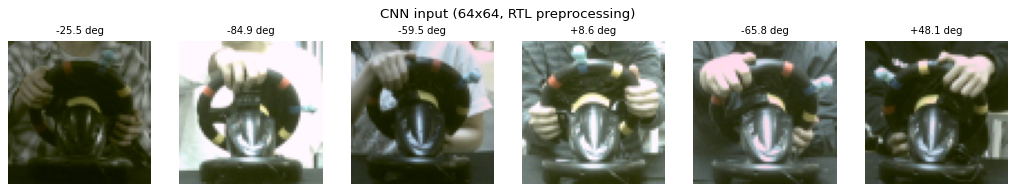

In [6]:
X = np.concatenate(X_parts); del X_parts
labels = pd.concat(meta_parts, ignore_index=True)
assert len(X) == len(labels)
Y = labels['angle_deg'].values.astype(np.float32)
IDX = {s: np.where(labels['split'].values == s)[0] for s in ('train', 'val', 'test', 'test_bg')}
print({s: len(v) for s, v in IDX.items()}, '| 각도 범위 %.1f ~ %.1f°' % (Y.min(), Y.max()))
print(labels.assign(dataset=labels['dataset'].map(lambda d: DS_NAMES[d])).groupby(['dataset', 'split']).size().unstack(fill_value=0).to_string())
assert np.abs(Y).max() <= 127, 'HW 출력이 INT8(1 LSB = 1°)이라 ±127° 를 넘는 라벨은 표현할 수 없습니다'

X_t = torch.from_numpy(X)            # uint8 로 메모리에 두고, 배치마다 INT8 값의 float 로 변환
Y_t = torch.from_numpy(Y)

def to_input(x_u8):
    # (N,64,64,3) uint8 → (N,3,64,64) float, 값은 INT8 정수 (uint8 - 128) : act_ld_unit 의 ^0x80
    return (x_u8.to(DEVICE).float() - 128.0).permute(0, 3, 1, 2)

fig, ax = plt.subplots(1, 6, figsize=(13, 2.4))
for a, i in zip(ax, IDX['val'][np.linspace(0, len(IDX['val']) - 1, 6).astype(int)]):
    a.imshow(X[i]); a.set_title(f'{Y[i]:+.1f} deg', fontsize=9); a.axis('off')
plt.suptitle('CNN input (64x64, RTL preprocessing)'); plt.tight_layout(); plt.show()

### 배경 교체 증강 결과 확인

**실제로 모델에 들어가는 64x64 입력** 기준으로, 같은 원본에서 나온 사본들을 한 줄에 나란히 보여 줍니다 (캐시에서 불러온 경우에도 동작).  
`orig` = 원본, `bg` = 배경만 바꾼 사본, `aug N` = 랜덤 증강본(절반 정도는 배경도 바뀜). 한 줄 안에서 핸들 모양과 각도는 같고 배경만 달라야 합니다.

종류별 장수:
kind       aug     bg  bright   orig
split                               
test         0      0       0   4498
test_bg      0   4498       0      0
train    61911  73074   36537  36537
val          0      0       0   4528


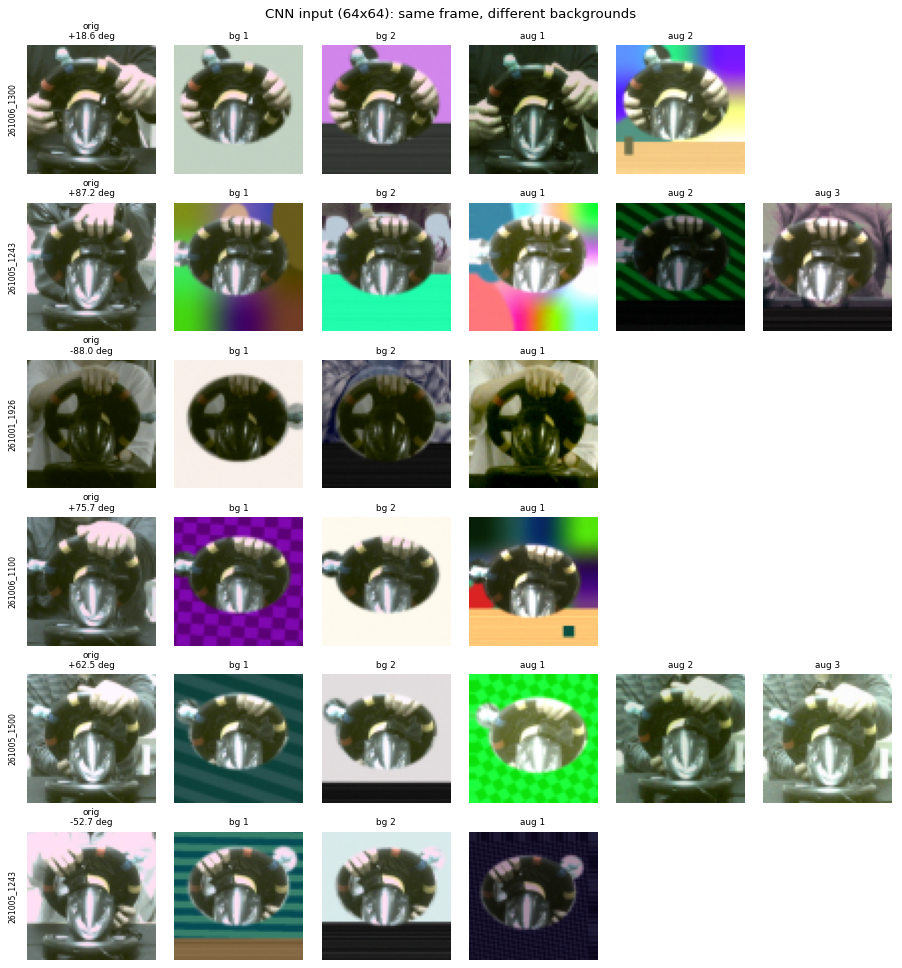

In [7]:
def show_bg_aug(n_rows=6, seed=0, n_cols=6):
    print('종류별 장수:'); print(labels.groupby(['split', 'kind']).size().unstack(fill_value=0).to_string())
    tr = labels[labels['split'] == 'train']
    cand = tr[tr['kind'] == 'bg']
    if len(cand) == 0:
        print('배경 교체 사본이 없습니다. 설정의 BG_AUG / N_BG_COPY 를 확인하세요.'); return
    pick = cand.sample(min(n_rows, len(cand)), random_state=seed)
    fig, axes = plt.subplots(len(pick), n_cols, figsize=(1.9 * n_cols, 2.05 * len(pick)), squeeze=False)
    for r, (_, p) in enumerate(pick.iterrows()):
        grp = tr[(tr['dataset'] == p['dataset']) & (tr['filename'] == p['filename'])]
        order = pd.concat([grp[grp['kind'] == k] for k in ('orig', 'bg', 'aug')]).head(n_cols)      # labels 의 index = X 의 행 번호
        for c in range(n_cols):
            ax = axes[r, c]; ax.axis('off')
            if c >= len(order): continue
            row = order.iloc[c]
            ax.imshow(X[order.index[c]])
            name = {'orig': 'orig', 'bg': f"bg {-row['aug_id']}", 'aug': f"aug {row['aug_id']}"}[row['kind']]
            ax.set_title(f"{name}\n{row['angle_deg']:+.1f} deg" if c == 0 else name, fontsize=8)
        axes[r, 0].text(-0.08, 0.5, DS_NAMES[p['dataset']].replace('dataset_', ''), transform=axes[r, 0].transAxes, rotation=90, va='center', ha='right', fontsize=7)
    plt.suptitle('CNN input (64x64): same frame, different backgrounds'); plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'bg_aug_inputs.jpg'), dpi=100); plt.show()

show_bg_aug(n_rows=6, seed=0)      # seed 를 바꾸면 다른 프레임을 보여 줌

## 6. 모델과 정수 golden 모델

`forward_fp32` 는 일반 float 연산, `forward_qat` 는 RTL 정수 연산(가중치/bias 정수화, `acc * M` → 0에서 먼 쪽 반올림 → ReLU → INT8 포화)을 흉내 낸 연산입니다.  
평가와 추출은 float 를 쓰지 않는 `hw_infer()` (RTL 과 같은 계산) 기준입니다.

In [8]:
S_IN = 1.0 / 128.0      # 입력 INT8 1 LSB 의 float 값
QS   = 30               # requant shift (RTL L0~L3_QS)

def ste(x, fn):         # 순전파는 fn(x), 역전파는 기울기 그대로 통과
    return x + (fn(x) - x).detach()

def round_away(x):      # 0 에서 먼 쪽으로 반올림 (RTL post_process 와 동일)
    return torch.sign(x) * torch.floor(torch.abs(x) + 0.5)

class ModelC(nn.Module):
    # C_6-4_FC32 : Conv(3→6)+ReLU+MaxPool → Conv(6→4)+ReLU → fc(4096→32)+ReLU → fc(32→1)
    def __init__(self):
        super().__init__()
        self.conv0 = nn.Conv2d(3, 6, 3, padding=1)
        self.conv1 = nn.Conv2d(6, 4, 3, padding=1)
        self.fc1 = nn.Linear(32 * 32 * 4, 32)
        self.fc2 = nn.Linear(32, 1)
        self.register_buffer('act_scale', torch.ones(3))     # Conv0 / Conv1 / fc1 출력의 1 LSB 값 (calibration 에서 결정)

    def layers(self):     return [self.conv0, self.conv1, self.fc1, self.fc2]
    def in_scales(self):  return [S_IN, self.act_scale[0], self.act_scale[1], self.act_scale[2]]
    def out_scales(self): return [self.act_scale[0], self.act_scale[1], self.act_scale[2], 1.0 / ANGLE_NORM]

    @staticmethod
    def flatten_hwc(x):   # fc1 입력 순서 = RTL 저장 순서 (y, x, c)
        return x.permute(0, 2, 3, 1).reshape(x.shape[0], -1)

    def forward_fp32(self, x, return_acts=False):
        a0 = F.relu(self.conv0(x * S_IN))
        a1 = F.relu(self.conv1(F.max_pool2d(a0, 2)))
        a2 = F.relu(self.fc1(self.flatten_hwc(a1)))
        out = self.fc2(a2).squeeze(1) * ANGLE_NORM            # deg
        return (out, [a0, a1, a2]) if return_acts else out

    def quantized(self, l):
        # 레이어 l 의 (정수 가중치, 정수 bias, M/2^30) - 값은 정수지만 float 텐서, STE 적용
        layer, s_in, s_out = self.layers()[l], self.in_scales()[l], self.out_scales()[l]
        sw = layer.weight.detach().abs().max().clamp_min(1e-8) / 127.0
        wq = ste(layer.weight / sw, torch.round)             # |W/sw| <= 127 이므로 별도 clamp 없음 (clamp 를 넣으면 가장 큰 가중치의 기울기가 막힘)
        bq = ste(layer.bias / (s_in * sw), torch.round)
        M = torch.round(s_in * sw / s_out * 2 ** QS) / 2 ** QS
        return wq, bq, M

    def forward_qat(self, x):
        w, b, M = self.quantized(0)
        q = ste(F.conv2d(x, w, b, padding=1) * M, round_away).clamp(0, 127)       # requant → ReLU → 포화
        q = F.max_pool2d(q, 2)
        w, b, M = self.quantized(1)
        q = ste(F.conv2d(q, w, b, padding=1) * M, round_away).clamp(0, 127)
        w, b, M = self.quantized(2)
        q = ste(F.linear(self.flatten_hwc(q), w, b) * M, round_away).clamp(0, 127)
        w, b, M = self.quantized(3)
        return (F.linear(q, w, b) * M).squeeze(1)             # deg (마지막 반올림 전 값 → loss 계산용)

model = ModelC().to(DEVICE)
print('파라미터 수:', sum(p.numel() for p in model.parameters()))

파라미터 수: 131525


In [9]:
@torch.no_grad()
def export_int_params(model):
    s_in  = [S_IN] + [float(a) for a in model.act_scale]
    s_out = [float(a) for a in model.act_scale] + [1.0 / ANGLE_NORM]
    P = dict(W=[], B=[], M=[], S=QS)
    for l, layer in enumerate(model.layers()):
        W = layer.weight.detach().double().cpu()
        sw = max(float(W.abs().max()), 1e-8) / 127.0
        Wq = torch.round(W / sw).clamp(-127, 127).long()
        if Wq.dim() == 4:                                            # (oc, c, ky, kx) → (oc, K), K 순서 = (ky, kx, c)
            Wq = Wq.permute(0, 2, 3, 1).reshape(Wq.shape[0], -1)
        Bq = torch.round(layer.bias.detach().double().cpu() / (s_in[l] * sw)).long()
        M = int(round(s_in[l] * sw / s_out[l] * 2 ** QS))
        assert 0 < M < 2 ** 31, f'L{l} 의 M={M} 이 32bit 범위를 벗어남'
        assert int(Bq.abs().max()) < 2 ** 31, f'L{l} bias 가 INT32 범위를 벗어남'
        P['W'].append(Wq.numpy()); P['B'].append(Bq.numpy()); P['M'].append(M)
    return P

def requant(acc, M, S, relu):
    # acc: int64 (bias 포함).  (acc*M) 를 0 에서 먼 쪽으로 반올림해서 >> S, ReLU, INT8 포화
    assert int(acc.abs().max()) < 2 ** 31, 'PE 누산기(INT32) 오버플로'
    p = acc * M
    half = 1 << (S - 1)
    p = (p + torch.where(p < 0, half - 1, half)) >> S
    if relu: p = p.clamp_min(0)
    return p.clamp(-128, 127)

@torch.no_grad()
def hw_infer(x_u8, P, chunk=256):
    W = [torch.from_numpy(w) for w in P['W']]; B = [torch.from_numpy(b) for b in P['B']]; M, S = P['M'], P['S']
    W0 = W[0].reshape(6, 3, 3, 3).permute(0, 3, 1, 2).double()       # (oc, ky, kx, c) → conv2d 형식
    W1 = W[1].reshape(4, 3, 3, 6).permute(0, 3, 1, 2).double()
    out = []
    for i in range(0, len(x_u8), chunk):
        x = torch.from_numpy(np.asarray(x_u8[i:i + chunk]).astype(np.int64) - 128).permute(0, 3, 1, 2).double()
        acc = F.conv2d(x, W0, padding=1).round().long() + B[0].view(1, -1, 1, 1)     # double 로 계산해도 2^53 미만이라 정확
        q = F.max_pool2d(requant(acc, M[0], S, True).double(), 2)
        acc = F.conv2d(q, W1, padding=1).round().long() + B[1].view(1, -1, 1, 1)
        q = requant(acc, M[1], S, True)
        flat = q.permute(0, 2, 3, 1).reshape(q.shape[0], -1).double()                # HWC
        q = requant((flat @ W[2].double().T).round().long() + B[2], M[2], S, True)
        ang = requant((q.double() @ W[3].double().T).round().long() + B[3], M[3], S, False)
        out.append(ang.squeeze(1).numpy())
    return np.concatenate(out).astype(np.int8)

def metrics(pred, y):
    e = np.abs(np.asarray(pred, np.float64) - y)
    return dict(mae=float(e.mean()), acc5=float((e <= 5).mean() * 100), acc10=float((e <= 10).mean() * 100))

## 7. 학습

매 epoch 끝에 `OUT_DIR/last.pt` 가 저장됩니다. `RESUME_FROM` 을 지정하면 그 지점부터 이어서 하며 epoch 수는 누적 기준입니다.  
(이어서 학습할 때는 **캐시와 같은 설정·같은 데이터셋 목록**이어야 val/test 가 섞이지 않습니다.)

In [10]:
state = dict(phase='fp32', epoch=0, history=[], best={})       # best[phase] = dict(mae, epoch, model)
optim_state = None

def save_ckpt(path):
    torch.save(dict(model=model.state_dict(), optim=optim_state, phase=state['phase'], epoch=state['epoch'],
                    history=state['history'], best=state['best'],
                    config=dict(ANGLE_NORM=ANGLE_NORM, ACT_PERCENTILE=ACT_PERCENTILE, QS=QS, S_IN=S_IN)), path)

def load_ckpt(path):
    global optim_state
    if path.lower().endswith('.zip'):
        with zipfile.ZipFile(path) as z:
            ck = torch.load(io.BytesIO(z.read('checkpoint.pt')), map_location=DEVICE, weights_only=False)
    else:
        ck = torch.load(path, map_location=DEVICE, weights_only=False)
    assert ck['config']['ANGLE_NORM'] == ANGLE_NORM, 'ANGLE_NORM 이 체크포인트와 다릅니다'
    model.load_state_dict(ck['model']); optim_state = ck['optim']
    state.update(phase=ck['phase'], epoch=ck['epoch'], history=ck['history'], best=ck['best'])
    print(f"체크포인트 불러옴: {path}  (단계={state['phase']}, epoch={state['epoch']})")

@torch.no_grad()
def predict_fp32(idx):
    model.eval()
    return np.concatenate([model.forward_fp32(to_input(X_t[idx[i:i + 512]])).cpu().numpy() for i in range(0, len(idx), 512)])

def evaluate(phase, idx):
    if phase == 'fp32': return metrics(predict_fp32(idx), Y[idx])
    return metrics(hw_infer(X[idx], export_int_params(model)), Y[idx])

def run_phase(phase, total_epochs, base_lr):
    global optim_state
    order = ['fp32', 'qat']
    if order.index(state['phase']) > order.index(phase):
        print(f'[{phase}] 체크포인트가 이미 다음 단계라 건너뜀'); return
    if state['epoch'] >= total_epochs:
        print(f"[{phase}] 이미 {state['epoch']} epoch 완료 (목표 {total_epochs}) → 추가 학습 없음")
    opt = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=WEIGHT_DECAY)
    if optim_state is not None and optim_state.get('phase') == phase:
        opt.load_state_dict(optim_state['state'])
    fwd = model.forward_fp32 if phase == 'fp32' else model.forward_qat
    tr = IDX['train']
    for ep in range(state['epoch'], total_epochs):
        for g in opt.param_groups:
            g['lr'] = base_lr * (0.02 + 0.98 * 0.5 * (1 + np.cos(np.pi * ep / total_epochs)))
        model.train(); t0 = time.time(); tot = 0.0
        perm = tr[torch.randperm(len(tr), generator=torch.Generator().manual_seed(SEED * 1000 + ep + (0 if phase == 'fp32' else 500))).numpy()]
        for i in range(0, len(perm), BATCH):
            b = perm[i:i + BATCH]
            loss = F.smooth_l1_loss(fwd(to_input(X_t[b])) / ANGLE_NORM, Y_t[b].to(DEVICE) / ANGLE_NORM, beta=0.05)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(b)
        v = evaluate(phase, IDX['val'])
        state['epoch'] = ep + 1
        state['history'].append(dict(phase=phase, epoch=ep + 1, loss=tot / len(perm), val_mae=v['mae'], val_acc5=v['acc5']))
        mark = ''
        if phase not in state['best'] or v['mae'] < state['best'][phase]['mae']:
            state['best'][phase] = dict(mae=v['mae'], epoch=ep + 1, model={k: t.detach().cpu().clone() for k, t in model.state_dict().items()})
            mark = ' *'
        optim_state = dict(phase=phase, state=opt.state_dict())
        save_ckpt(os.path.join(OUT_DIR, 'last.pt'))
        print(f"[{phase}] epoch {ep + 1:3d}/{total_epochs}  loss {tot / len(perm):.5f}  val MAE {v['mae']:.2f}°  ±5° {v['acc5']:.1f}%  ({time.time() - t0:.0f}s){mark}")

def make_resume_zip():
    # 이어서 학습용 체크포인트 묶음
    save_ckpt(os.path.join(OUT_DIR, 'last.pt'))
    path = os.path.join(OUT_DIR, f"ModelC_RESUME_{state['phase']}_epoch{state['epoch']:04d}_{STAMP}.zip")
    with zipfile.ZipFile(path, 'w', zipfile.ZIP_DEFLATED) as z:
        z.write(os.path.join(OUT_DIR, 'last.pt'), 'checkpoint.pt')
        z.writestr('split.csv', labels[['dataset', 'filename', 'split']].to_csv(index=False))
        z.writestr('history.csv', pd.DataFrame(state['history']).to_csv(index=False))
    return path

if RESUME_FROM:
    load_ckpt(RESUME_FROM)
    # 데이터가 바뀌었을 수 있으므로, 저장돼 있던 best 모델을 지금의 val 로 다시 평가해서 비교 기준을 맞춘다
    current = {k: v.clone() for k, v in model.state_dict().items()}
    for ph, b in state['best'].items():
        model.load_state_dict(b['model']); b['mae'] = evaluate(ph, IDX['val'])['mae']
        print(f"  이전 best ({ph} epoch {b['epoch']}) 를 지금 val 로 다시 평가: MAE {b['mae']:.2f}°")
    model.load_state_dict(current)

In [11]:
run_phase('fp32', EPOCHS_FP32, LR_FP32)

[fp32] epoch   1/40  loss 0.05079  val MAE 2.14°  ±5° 92.2%  (13s) *
[fp32] epoch   2/40  loss 0.01951  val MAE 2.09°  ±5° 92.7%  (10s) *
[fp32] epoch   3/40  loss 0.01466  val MAE 1.63°  ±5° 97.1%  (9s) *
[fp32] epoch   4/40  loss 0.01275  val MAE 1.57°  ±5° 97.3%  (10s) *
[fp32] epoch   5/40  loss 0.01175  val MAE 2.24°  ±5° 93.2%  (10s)
[fp32] epoch   6/40  loss 0.01090  val MAE 1.49°  ±5° 98.0%  (9s) *
[fp32] epoch   7/40  loss 0.01023  val MAE 1.45°  ±5° 98.3%  (10s) *
[fp32] epoch   8/40  loss 0.00956  val MAE 1.71°  ±5° 96.2%  (10s)
[fp32] epoch   9/40  loss 0.00910  val MAE 1.31°  ±5° 98.9%  (10s) *
[fp32] epoch  10/40  loss 0.00861  val MAE 1.34°  ±5° 98.9%  (10s)
[fp32] epoch  11/40  loss 0.00827  val MAE 1.42°  ±5° 97.8%  (10s)
[fp32] epoch  12/40  loss 0.00795  val MAE 1.23°  ±5° 99.0%  (10s) *
[fp32] epoch  13/40  loss 0.00761  val MAE 1.53°  ±5° 98.4%  (9s)
[fp32] epoch  14/40  loss 0.00728  val MAE 1.46°  ±5° 98.9%  (10s)
[fp32] epoch  15/40  loss 0.00695  val MAE 1.26° 

In [12]:
if state['phase'] == 'fp32':
    model.load_state_dict(state['best']['fp32']['model'])
    model.eval()
    sub = IDX['train'][np.random.default_rng(SEED).permutation(len(IDX['train']))[:2000]]
    acts = [[], [], []]
    with torch.no_grad():
        for i in range(0, len(sub), 250):
            _, a = model.forward_fp32(to_input(X_t[sub[i:i + 250]]), return_acts=True)
            for k in range(3):
                v = a[k].flatten()
                acts[k].append(v[torch.randperm(len(v))[:200000]].cpu().numpy())
    for k in range(3):
        model.act_scale[k] = max(float(np.percentile(np.concatenate(acts[k]), ACT_PERCENTILE)), 1e-6) / 127.0
    state.update(phase='qat', epoch=0)
    optim_state = None
    print('calibration 직후 (PTQ) val INT8:', evaluate('qat', IDX['val']))
print('act_scale:', [round(float(a), 6) for a in model.act_scale])

calibration 직후 (PTQ) val INT8: {'mae': 1.3606117371203996, 'acc5': 98.67491166077738, 'acc10': 99.95583038869258}
act_scale: [0.009204, 0.004146, 0.032407]


In [13]:
run_phase('qat', EPOCHS_QAT, LR_QAT)
resume_zip = make_resume_zip()                              # 마지막 epoch 상태 = 이어서 학습용
print('이어서 학습용 체크포인트:', resume_zip)

model.load_state_dict(state['best']['qat']['model'])       # export 는 val INT8 MAE 가 가장 좋았던 epoch 의 가중치로
print(f"export 에 쓸 모델: QAT epoch {state['best']['qat']['epoch']} (val INT8 MAE {state['best']['qat']['mae']:.2f}°)")

[qat] epoch   1/20  loss 0.00521  val MAE 1.19°  ±5° 99.2%  (26s) *
[qat] epoch   2/20  loss 0.00499  val MAE 1.10°  ±5° 99.6%  (26s) *
[qat] epoch   3/20  loss 0.00495  val MAE 1.14°  ±5° 99.5%  (26s)
[qat] epoch   4/20  loss 0.00491  val MAE 1.52°  ±5° 98.7%  (26s)
[qat] epoch   5/20  loss 0.00481  val MAE 1.20°  ±5° 99.4%  (27s)
[qat] epoch   6/20  loss 0.00478  val MAE 1.22°  ±5° 99.5%  (26s)
[qat] epoch   7/20  loss 0.00469  val MAE 1.09°  ±5° 99.6%  (26s) *
[qat] epoch   8/20  loss 0.00468  val MAE 1.31°  ±5° 99.2%  (26s)
[qat] epoch   9/20  loss 0.00461  val MAE 1.15°  ±5° 99.5%  (26s)
[qat] epoch  10/20  loss 0.00453  val MAE 1.13°  ±5° 99.5%  (26s)
[qat] epoch  11/20  loss 0.00442  val MAE 1.12°  ±5° 99.6%  (26s)
[qat] epoch  12/20  loss 0.00437  val MAE 1.06°  ±5° 99.8%  (26s) *
[qat] epoch  13/20  loss 0.00428  val MAE 1.08°  ±5° 99.6%  (27s)
[qat] epoch  14/20  loss 0.00422  val MAE 1.08°  ±5° 99.6%  (26s)
[qat] epoch  15/20  loss 0.00414  val MAE 1.05°  ±5° 99.6%  (26s) *


## 8. 평가 (FP32 vs HW 와 같은 INT8)

split     model  mae  acc5  acc10
  val      FP32 1.23 99.16  99.96
  val INT8 (HW) 1.03 99.67  99.96
 test      FP32 1.22 99.53  99.91
 test INT8 (HW) 1.04 99.44  99.91
  test / dataset 0 (dataset_261001_1926): 360 장, INT8 MAE 0.86°, ±5° 100.0%, ±10° 100.0%
  test / dataset 1 (dataset_261001_2030): 177 장, INT8 MAE 0.94°, ±5° 100.0%, ±10° 100.0%
  test / dataset 2 (dataset_261002_1400): 359 장, INT8 MAE 0.95°, ±5° 100.0%, ±10° 100.0%
  test / dataset 3 (dataset_261002_1700): 575 장, INT8 MAE 0.82°, ±5° 99.8%, ±10° 100.0%
  test / dataset 4 (dataset_261004_1530): 393 장, INT8 MAE 1.15°, ±5° 99.2%, ±10° 99.7%
  test / dataset 5 (dataset_261005_1243): 566 장, INT8 MAE 1.44°, ±5° 99.5%, ±10° 99.6%
  test / dataset 6 (dataset_261005_1500): 511 장, INT8 MAE 0.89°, ±5° 100.0%, ±10° 100.0%
  test / dataset 7 (dataset_261006_0700): 431 장, INT8 MAE 0.90°, ±5° 100.0%, ±10° 100.0%
  test / dataset 8 (dataset_261006_1100): 562 장, INT8 MAE 1.15°, ±5° 98.8%, ±10° 100.0%
  test / dataset 9 (dataset_261006_

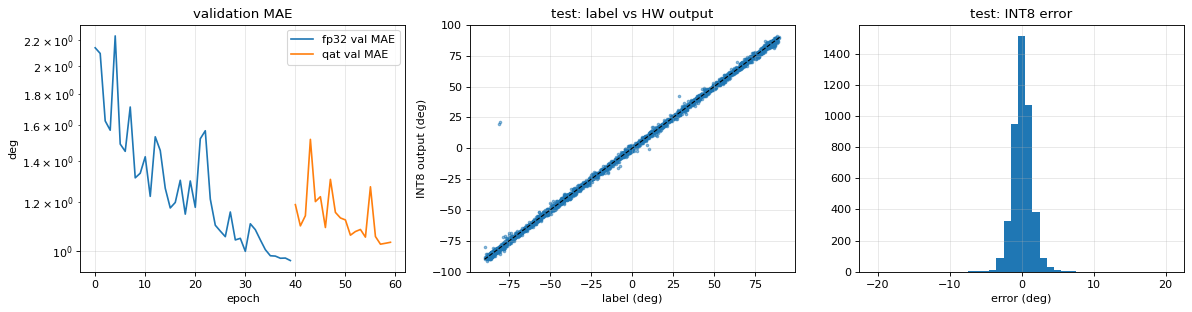

In [14]:
P = export_int_params(model)
rows = []
pred = {}
for s in ('val', 'test'):
    pred[s] = hw_infer(X[IDX[s]], P)
    rows.append(dict(split=s, model='FP32', **metrics(predict_fp32(IDX[s]), Y[IDX[s]])))
    rows.append(dict(split=s, model='INT8 (HW)', **metrics(pred[s], Y[IDX[s]])))
report = pd.DataFrame(rows).round(2)
print(report.to_string(index=False))

# 데이터셋별 INT8 결과 (test)
ds_test = labels['dataset'].values[IDX['test']]
for d in sorted(set(ds_test)):
    m = metrics(pred['test'][ds_test == d], Y[IDX['test']][ds_test == d])
    print(f"  test / dataset {d} ({DS_NAMES[d]}): {int((ds_test == d).sum())} 장, INT8 MAE {m['mae']:.2f}°, ±5° {m['acc5']:.1f}%, ±10° {m['acc10']:.1f}%")

# 배경을 바꾼 test (같은 이미지, 같은 라벨, 배경만 임의로 교체). 위의 test 와 차이가 작을수록 배경에 덜 끌려가는 모델
if len(IDX['test_bg']):
    m = metrics(hw_infer(X[IDX['test_bg']], P), Y[IDX['test_bg']])
    print(f"  test (배경 교체) {len(IDX['test_bg'])} 장: INT8 MAE {m['mae']:.2f}°, ±5° {m['acc5']:.1f}%, ±10° {m['acc10']:.1f}%")

yt, pt = Y[IDX['test']], pred['test'].astype(np.float64)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
h = pd.DataFrame(state['history'])
for ph, c in (('fp32', 'C0'), ('qat', 'C1')):
    d = h[h['phase'] == ph]
    ax[0].plot(np.arange(len(d)) + (0 if ph == 'fp32' else (h['phase'] == 'fp32').sum()), d['val_mae'], c, label=f'{ph} val MAE')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('deg'); ax[0].set_yscale('log'); ax[0].legend(); ax[0].set_title('validation MAE')
ax[1].scatter(yt, pt, s=5, alpha=0.5); ax[1].plot([-90, 90], [-90, 90], 'k--', lw=1)
ax[1].set_xlabel('label (deg)'); ax[1].set_ylabel('INT8 output (deg)'); ax[1].set_title('test: label vs HW output')
ax[2].hist(pt - yt, bins=41, range=(-20.5, 20.5)); ax[2].set_xlabel('error (deg)'); ax[2].set_title('test: INT8 error')
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'evaluation.png')); plt.show()

## 9. HW 추출

공유 RAM (32bit x 59,993 word): word 0~45249 가중치(INT8, 3개씩 묶음), 45250~45292 bias(INT32), 45293~ 는 `BASE_COE` 에서 복사.  
**보드에 올릴 때는 COE 교체와 함께 `top_cnn.v` 의 `L0~L3_QM` 을 아래 VH 값으로 바꾸고 IP 재패키징 → 업그레이드 → 비트스트림 재생성까지 해야 합니다.**

In [15]:
W_BASE, PRM_BASE, IMG_START, TOTAL_WORDS = [0, 54, 162, 45218], 45250, 45293, 59993

def pack_weights(Wk):
    # (oc, K) 정수 → 24bit word 배열 (그룹 우선, 그룹 안에서는 K 순서)
    oc, K = Wk.shape
    words = np.zeros(((oc + 2) // 3, K), np.uint32)
    for lane in range(3):
        sel = Wk[lane::3]                                    # oc = 3g + lane
        words[:len(sel)] |= (sel & 0xFF).astype(np.uint32) << (8 * lane)
    return words.reshape(-1)

def read_coe(path):
    body = open(path, encoding='utf-8-sig').read().split('memory_initialization_vector=', 1)[1]
    return np.array([int(v, 16) for v in re.findall(r'[0-9a-fA-F]+', body)], dtype=np.uint32)

def write_coe(path, words):
    with open(path, 'w', newline='\n') as f:
        f.write('memory_initialization_radix=16;\nmemory_initialization_vector=\n')
        f.write(',\n'.join(f'{int(w):08X}' for w in words) + ';\n')

wgt = np.concatenate([pack_weights(w) for w in P['W']])
prm = np.concatenate(P['B']).astype(np.int64).astype(np.uint32)                 # INT32 2의 보수
assert len(wgt) == PRM_BASE and len(prm) == IMG_START - PRM_BASE

ram = np.zeros(TOTAL_WORDS, np.uint32)
ram[:PRM_BASE] = wgt; ram[PRM_BASE:IMG_START] = prm
if BASE_COE and os.path.exists(BASE_COE):
    base = read_coe(BASE_COE)
    assert len(base) == TOTAL_WORDS, f'BASE_COE 의 word 수가 {len(base)} (기대값 {TOTAL_WORDS})'
    ram[IMG_START:] = base[IMG_START:]
    print(f'word {IMG_START}~ 는 {BASE_COE} 에서 복사')
else:
    print(f'BASE_COE 가 없어 word {IMG_START}~ 는 0 으로 채움')

coe_path = os.path.join(OUT_DIR, f'Weight_Bias_Image_{STAMP}.coe')
vh_path  = os.path.join(OUT_DIR, f'cnn_cntl_quant_params_{STAMP}.vh')
write_coe(coe_path, ram)

vh = ['// Paste these values into top_cnn / top_cnn_cntl / cnn_cntl parameters.']
for l in range(4):
    if l == 3: vh.append('// L3_QM/QS = Final ANGLE_MULT/ANGLE_SHIFT')
    vh.append(f"parameter [31:0] L{l}_QM = 32'd{P['M'][l]},")
    vh.append(f"parameter [ 5:0] L{l}_QS = 6'd{P['S']}" + (',' if l < 3 else ''))
open(vh_path, 'w', newline='\n').write('\n'.join(vh) + '\n')
print(open(vh_path).read())

# --- RTL 시뮬레이션용 mem (tb_top_cnn_board.v 와 같은 파일 이름) ---
pick = IDX['test'][np.linspace(0, len(IDX['test']) - 1, N_TEST_VECTORS).astype(int)]
exp = hw_infer(X[pick], P)
img_words = (X[pick].astype(np.uint32)[..., 0] << 16) | (X[pick].astype(np.uint32)[..., 1] << 8) | X[pick].astype(np.uint32)[..., 2]
mem = {'wgt.mem': [f'{w:06X}' for w in wgt], 'prm.mem': [f'{w:08X}' for w in prm],
       'img.mem': [f'{w:06x}' for w in img_words.reshape(-1)],                      # 이미지 RAM 형식 = {R, G, B} uint8 (CAPTURE 출력)
       'expected_angles.mem': [f'{int(a) & 0xFF:02X}' for a in exp]}
for name, lines in mem.items():
    open(os.path.join(OUT_DIR, name), 'w', newline='\n').write('\n'.join(lines) + '\n')
tv = pd.DataFrame(dict(index=range(len(pick)), dataset=labels['dataset'].values[pick], filename=labels['filename'].values[pick], label_deg=Y[pick], expected_int8=exp,
                       expected_hex=[f'{int(a) & 0xFF:02X}' for a in exp]))
tv.to_csv(os.path.join(OUT_DIR, 'test_vectors.csv'), index=False)
print(tv.to_string(index=False))

BASE_COE 가 없어 word 45293~ 는 0 으로 채움
// Paste these values into top_cnn / top_cnn_cntl / cnn_cntl parameters.
parameter [31:0] L0_QM = 32'd2589547,
parameter [ 5:0] L0_QS = 6'd30,
parameter [31:0] L1_QM = 32'd8470202,
parameter [ 5:0] L1_QS = 6'd30,
parameter [31:0] L2_QM = 32'd6154952,
parameter [ 5:0] L2_QS = 6'd30,
// L3_QM/QS = Final ANGLE_MULT/ANGLE_SHIFT
parameter [31:0] L3_QM = 32'd3970754,
parameter [ 5:0] L3_QS = 6'd30

 index  dataset           filename  label_deg  expected_int8 expected_hex
     0        0  capture_00320.png  26.080000             27           1B
     1        3  capture_27310.png -75.349998            -75           B5
     2        5  capture_66853.png -73.930000            -77           B3
     3        8 capture_104052.png  54.520000             56           38
     4        9 capture_163646.png  38.540001             38           26


In [16]:
def params_from_files(coe_file, vh_file):
    w = read_coe(coe_file)
    s8 = lambda v: ((v.astype(np.int64) + 128) & 0xFF) - 128
    shapes = [(6, 27), (4, 54), (32, 4096), (1, 32)]
    Wl = []
    for (oc, K), base in zip(shapes, W_BASE):
        g = w[base:base + ((oc + 2) // 3) * K].reshape(-1, K)
        Wk = np.zeros((oc, K), np.int64)
        for lane in range(3):
            rows = Wk[lane::3]; rows[:] = s8((g[:len(rows)] >> (8 * lane)) & 0xFF)
        Wl.append(Wk)
    b = w[PRM_BASE:IMG_START].astype(np.int64); b = np.where(b >= 2 ** 31, b - 2 ** 32, b)
    Bl = [b[0:6], b[6:10], b[10:42], b[42:43]]
    txt = open(vh_file).read()
    Ml = [int(re.search(rf"L{l}_QM = 32'd(\d+)", txt).group(1)) for l in range(4)]
    return dict(W=Wl, B=Bl, M=Ml, S=int(re.search(r"L0_QS = 6'd(\d+)", txt).group(1)))

P_file = params_from_files(coe_path, vh_path)
chk = hw_infer(X[IDX['test']], P_file)
assert np.array_equal(chk, pred['test']), 'COE/VH 에서 복원한 결과가 모델과 다릅니다'
print(f"COE/VH 재검증 통과: test {len(chk)} 장 모두 일치  (INT8 MAE {metrics(chk, Y[IDX['test']])['mae']:.2f}°)")

zip_path = os.path.join(OUT_DIR, f'ModelC_HW_EXPORT_{STAMP}.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for p in [coe_path, vh_path, resume_zip, os.path.join(OUT_DIR, 'test_vectors.csv'), os.path.join(OUT_DIR, 'evaluation.png')] + [os.path.join(OUT_DIR, n) for n in mem]:
        z.write(p, os.path.basename(p))
    z.writestr('report.csv', report.to_csv(index=False))
    z.writestr('hw_params.json', json.dumps(dict(M=P['M'], S=P['S'], act_scale=[float(a) for a in model.act_scale], S_IN=S_IN,
                                                 ANGLE_NORM=ANGLE_NORM, CROP=[CROP_X, CROP_Y], best_epoch=state['best']['qat']['epoch']), indent=1))
print('저장 완료:', zip_path)
print('이어서 학습하려면: RESUME_FROM =', repr(resume_zip))

COE/VH 재검증 통과: test 4498 장 모두 일치  (INT8 MAE 1.04°)
저장 완료: /content/drive/MyDrive/OndeviceAI2/Team_4/SoC/CNN/dataset_front_view/261006/pipeline_out/ModelC_HW_EXPORT_20261007_1238.zip
이어서 학습하려면: RESUME_FROM = '/content/drive/MyDrive/OndeviceAI2/Team_4/SoC/CNN/dataset_front_view/261006/pipeline_out/ModelC_RESUME_qat_epoch0020_20261007_1238.zip'


## 10. 각도 구간별 test 결과 (끝 각도 점검)

특정 각도 범위(`ANGLE_RANGE`)의 test 이미지만 골라서 **보드에 올라갈 INT8 모델**의 결과를 봅니다.

1. 20° 구간별 표: 장수, 오차, 치우침(`bias` = 출력 - 라벨의 평균. 끝 각도에서 출력이 안쪽으로 당겨지면 - 쪽 끝은 +, + 쪽 끝은 - 로 나옴)
2. 범위 안 test 이미지 전체 목록 (CSV 저장)
3. 이미지와 라벨 / 출력 비교 그림 (오차 10° 초과는 빨간 글씨)
4. 같은 범위의 이미지로 만든 시뮬레이션·보드 확인용 `img_range.mem`, `expected_range.mem`

label range  test  train_orig  MAE  bias  ±5° %  ±10° %  out min  out max
  -90 ~ -70   969        7923 1.08  0.14   99.2    99.8      -91       21
  -70 ~ -50   510        4175 0.88  0.04   99.6   100.0      -72      -44
  -50 ~ -30   417        3420 1.14  0.18   99.8   100.0      -53      -28
  -30 ~ -10   301        2547 1.06 -0.09   99.7   100.0      -31       -9
  -10 ~ +10   582        4542 1.00  0.17   99.3    99.8      -16       11
  +10 ~ +30   313        2460 1.05  0.16   99.0    99.7        8       42
  +30 ~ +50   371        3139 0.99  0.26   99.2   100.0       28       53
  +50 ~ +70   379        3214 1.11  0.19   99.7   100.0       48       72
  +70 ~ +90   656        5103 1.05  0.05   99.7   100.0       69       91

라벨 -90° ~ -55° 인 test 이미지: 1351 장, INT8 MAE 1.01°, 출력 범위 -91 ~ 21
            dataset           filename  label_deg  out_int8  error
dataset_261006_1100 capture_114811.png     -89.66       -89   0.66
dataset_261006_1100 capture_111596.png     -89.64       -80

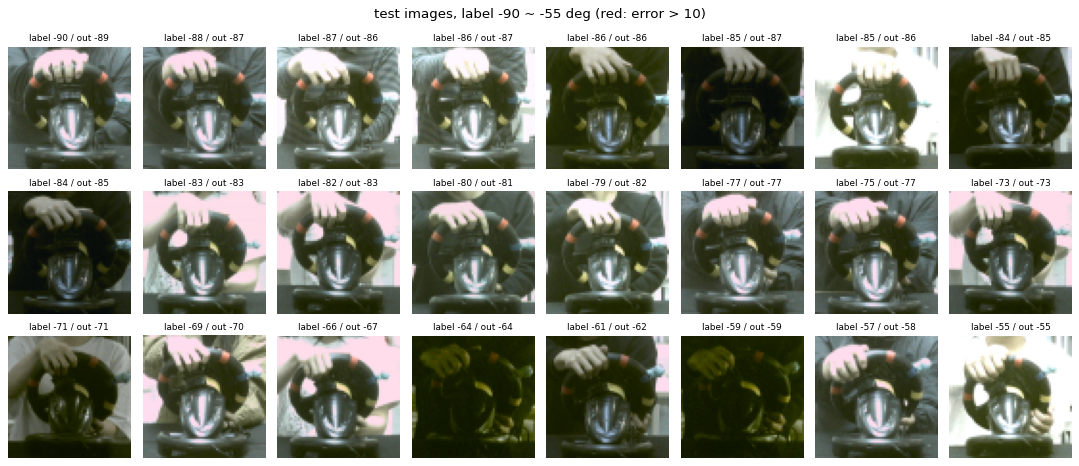


img_range.mem / expected_range.mem 저장 (10 장):
 index           filename  label_deg  expected_int8 expected_hex
     0 capture_114811.png     -89.66            -89           A7
     1  capture_44804.png     -86.29            -86           AA
     2  capture_46315.png     -85.19            -84           AC
     3  capture_27951.png     -84.04            -84           AC
     4  capture_29126.png     -81.48            -82           AE
     5  capture_14564.png     -77.52            -77           B3
     6  capture_61725.png     -72.54            -73           B7
     7  capture_39339.png     -66.61            -67           BD
     8  capture_14534.png     -60.19            -59           C5
     9  capture_25905.png     -55.02            -55           C9


In [17]:
ANGLE_RANGE = (-90, -55)     # 자세히 볼 라벨 각도 범위 (deg). + 쪽 끝을 보려면 (55, 90)
N_SHOW      = 24             # 그림으로 볼 최대 장수
N_MEM       = 10             # mem 파일에 넣을 장수

te = IDX['test']
y_te, p_te = Y[te], hw_infer(X[te], P).astype(np.float64)

# 1) 20도 구간별 결과 (train_orig = 그 구간의 train 원본 장수: 적으면 데이터 부족)
tr_orig = labels[(labels['split'] == 'train') & (labels['kind'] == 'orig')]['angle_deg'].values
rows = []
for lo in range(-90, 90, 20):
    hi = lo + 20
    m = (y_te >= lo) & ((y_te < hi) | (hi == 90))
    if not m.any(): continue
    e = p_te[m] - y_te[m]
    rows.append({'label range': f'{lo:+d} ~ {hi:+d}', 'test': int(m.sum()), 'train_orig': int(((tr_orig >= lo) & ((tr_orig < hi) | (hi == 90))).sum()),
                 'MAE': round(np.abs(e).mean(), 2), 'bias': round(e.mean(), 2), '±5° %': round((np.abs(e) <= 5).mean() * 100, 1),
                 '±10° %': round((np.abs(e) <= 10).mean() * 100, 1), 'out min': int(p_te[m].min()), 'out max': int(p_te[m].max())})
print(pd.DataFrame(rows).to_string(index=False))

# 2) 범위 안 test 이미지 목록
sel = np.where((y_te >= ANGLE_RANGE[0]) & (y_te <= ANGLE_RANGE[1]))[0]
sel = sel[np.argsort(y_te[sel])]
rng_tab = pd.DataFrame(dict(dataset=[DS_NAMES[d] for d in labels['dataset'].values[te[sel]]], filename=labels['filename'].values[te[sel]],
                            label_deg=np.round(y_te[sel].astype(float), 2), out_int8=p_te[sel].astype(int), error=(p_te[sel] - y_te[sel]).round(2)))
tag = f'{ANGLE_RANGE[0]}_{ANGLE_RANGE[1]}'
rng_tab.to_csv(os.path.join(OUT_DIR, f'test_range_{tag}.csv'), index=False)
print()
print(f"라벨 {ANGLE_RANGE[0]}° ~ {ANGLE_RANGE[1]}° 인 test 이미지: {len(sel)} 장" + (f", INT8 MAE {np.abs(rng_tab['error']).mean():.2f}°, 출력 범위 {rng_tab['out_int8'].min()} ~ {rng_tab['out_int8'].max()}" if len(sel) else ''))
if len(sel):
    print(rng_tab.to_string(index=False, max_rows=40))

    # 3) 그림: 라벨 순으로 고르게 뽑아 표시
    show = sel[np.linspace(0, len(sel) - 1, min(N_SHOW, len(sel))).astype(int)]
    cols = 8; nrow = int(np.ceil(len(show) / cols))
    fig, axes = plt.subplots(nrow, cols, figsize=(1.7 * cols, 2.0 * nrow), squeeze=False)
    for ax in axes.ravel(): ax.axis('off')
    for ax, i in zip(axes.ravel(), show):
        err = p_te[i] - y_te[i]
        ax.imshow(X[te[i]]); ax.set_title(f'label {y_te[i]:+.0f} / out {p_te[i]:+.0f}', fontsize=8, color='red' if abs(err) > 10 else 'black')
    plt.suptitle(f'test images, label {ANGLE_RANGE[0]} ~ {ANGLE_RANGE[1]} deg (red: error > 10)'); plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'test_range_{tag}.jpg'), dpi=100); plt.show()

    # 4) 시뮬레이션 / 보드 확인용 mem (img.mem 과 같은 형식: 이미지당 4096 word, {R, G, B} uint8)
    pick_r = te[sel[np.linspace(0, len(sel) - 1, min(N_MEM, len(sel))).astype(int)]]
    exp_r = hw_infer(X[pick_r], P)
    wr = (X[pick_r].astype(np.uint32)[..., 0] << 16) | (X[pick_r].astype(np.uint32)[..., 1] << 8) | X[pick_r].astype(np.uint32)[..., 2]
    with open(os.path.join(OUT_DIR, 'img_range.mem'), 'w') as f:
        for w in wr.reshape(-1): print(f'{w:06x}', file=f)
    with open(os.path.join(OUT_DIR, 'expected_range.mem'), 'w') as f:
        for a in exp_r: print(f'{int(a) & 0xFF:02X}', file=f)
    print()
    print(f'img_range.mem / expected_range.mem 저장 ({len(pick_r)} 장):')
    print(pd.DataFrame(dict(index=range(len(pick_r)), filename=labels['filename'].values[pick_r], label_deg=np.round(Y[pick_r].astype(float), 2), expected_int8=exp_r,
                            expected_hex=[f'{int(a) & 0xFF:02X}' for a in exp_r])).to_string(index=False))

## 11. 다운로드

In [18]:
print('결과 폴더:', OUT_DIR)
print('  HW 추출 묶음 :', zip_path)
print('  이어서 학습용:', resume_zip)
try:
    from google.colab import files as colab_files
    colab_files.download(zip_path)          # COE, VH, mem, RESUME zip 이 모두 들어 있는 묶음
except ImportError:
    pass

결과 폴더: /content/drive/MyDrive/OndeviceAI2/Team_4/SoC/CNN/dataset_front_view/261006/pipeline_out
  HW 추출 묶음 : /content/drive/MyDrive/OndeviceAI2/Team_4/SoC/CNN/dataset_front_view/261006/pipeline_out/ModelC_HW_EXPORT_20261007_1238.zip
  이어서 학습용: /content/drive/MyDrive/OndeviceAI2/Team_4/SoC/CNN/dataset_front_view/261006/pipeline_out/ModelC_RESUME_qat_epoch0020_20261007_1238.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>